### Niezbędne biblioteki

In [1]:
!pip install pandas
!pip install shap
!pip install xgboost scikit-learn pandas
!pip install lime
!pip install ipython==7.23.1


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Definicje funkcji

In [1]:
#------------------------------------------------- LIME ------------------------------------------------
from lime.lime_tabular import LimeTabularExplainer 

def return_lime_weights(exp, prediction_class_number, n_features): 
    exp_weight = np.zeros(n_features)
    for feature_id, weight in exp.as_map()[prediction_class_number]:
        exp_weight[feature_id] = weight

    return exp_weight 

def lime(model, X_train, class_names, sample_id): 
    feature_names = list(X_train.columns) 
    explainer_lime = LimeTabularExplainer( 
        X_train.values, feature_names = feature_names, class_names = class_names, mode = 'classification' 
    ) 
    
    exp_lime = explainer_lime.explain_instance( 
        X_train.iloc[sample_id].values, model.predict_proba, num_features = len(X_train.columns), top_labels = len(class_names) 
    ) 
    
    for label in exp_lime.top_labels: 
        exp_lime.as_pyplot_figure(label = label) 
        plt.show() 
        
    print("\n\n") 
    exp_lime.show_in_notebook() 
    print("\n\n") 

    overall_weights = []    
    for i in range(0, len(class_names)):
        weights = []
        for _, x in X_train.iterrows(): 
            predict_fn = lambda x: model.predict_proba(pd.DataFrame(x, columns=X_train.columns))
            
            exp = explainer_lime.explain_instance(
                x.values, predict_fn, num_features = len(X_train.columns), labels = list(range(len(class_names)))
            )
            exp_weight = return_lime_weights(exp, i, len(X_train.columns)) 
            weights.append(exp_weight)
            
        lime_weights = pd.DataFrame(data = weights, columns = X_train.columns) 
        
        abs_mean = lime_weights.abs().mean(axis=0).reset_index()
        abs_mean.columns = ['feature', 'abs_mean'] 
        abs_mean = abs_mean.sort_values('abs_mean') 
        overall_weights.append(abs_mean)

    print(np.shape(overall_weights))
    lime_matrix = pd.DataFrame({
        f"{i}": tab.set_index('feature')['abs_mean'] for i, tab in enumerate(overall_weights)
    })
    
    plt.figure()
    fig, ax = plt.subplots(1, 1, figsize = (20, 10))
    lime_matrix.plot.bar(ax = ax)
    ax.set_ylabel("Mean |LIME weight|")
    ax.set_xticklabels(lime_matrix.index, rotation=45)    
    ax.legend()
    plt.show()
    
    all_df = []

    for i, tab in enumerate(overall_weights):
        temp = tab.copy()
        temp['class'] = i
        all_df.append(temp)
    
    all_df = pd.concat(all_df, ignore_index=True)
    mean_over_classes = (
        all_df.groupby('feature')['abs_mean'].mean().reset_index().sort_values('abs_mean')
    )
    plt.figure(figsize=(8, 4))

    plt.barh(
        y=mean_over_classes['feature'], width = mean_over_classes['abs_mean']
    )
    
    plt.xlabel('Mean |Weight| across classes')
    plt.ylabel('')
    plt.title('Global feature importance (LIME)')
    plt.show()


#------------------------------------------------- SHAP ------------------------------------------------
import shap
import math
import numpy as np
import pandas as pd
shap.initjs()

def get_explainer(model, X_train):
    model_name = type(model).__name__
    
    if model_name in ["RandomForestClassifier", "XGBClassifier"]:
        return shap.Explainer(model)
    else:
        return shap.Explainer(model.predict_proba, X_train)

def multiclass_shap(model, X_train, class_names, sample_pos):
    explainer = get_explainer(model, X_train)
    shap_values = explainer(X_train)

    print(np.shape(shap_values))

    means = []
    for i in range(0, np.shape(shap_values)[2]):
        print(f"\nLocal explanation for class {i}")
        shap.plots.waterfall(shap_values[sample_pos, :, i])
        plt.show()
        means.append(np.mean(np.abs(shap_values.values[:, :, i]), axis = 0))

    plt.figure()
    df = pd.DataFrame({cl: mean for cl, mean in zip(class_names, means)})
    fig, ax = plt.subplots(1, 1, figsize = (20, 10))
    df.plot.bar(ax = ax)
    ax.set_ylabel("Mean SHAP")
    ax.set_xticklabels(X_train.columns, rotation = 45)
    ax.legend()
    plt.show()

    preds = model.predict(X_train)
    new_shap_values = []
    for i, pred in enumerate(preds):
        new_shap_values.append(shap_values.values[i][:, pred])

    shap_values.values = np.array(new_shap_values)
    print(shap_values.shape)

    plt.figure()
    shap.plots.bar(shap_values)
    plt.show()

    plt.figure()
    shap.plots.beeswarm(shap_values)
    plt.show()
        

#------------------------------------------------- PFI ------------------------------------------------
from sklearn.inspection import permutation_importance

def pfi(model, X_train, y_train):
    pfi = permutation_importance(model, X_train, y_train, n_repeats = 30, random_state = 42, n_jobs=2)

    for i in pfi.importances_mean.argsort()[::-1]:
        if pfi.importances_mean[i] - 2 * pfi.importances_std[i] > 0:
            print(f"{X_train.columns[i]:<8}"
                  f"{pfi.importances_mean[i]:.3f}"
                  f" +/- {pfi.importances_std[i]:.3f}")
    
    sorted_importances_idx = pfi.importances_mean.argsort()
    importances = pd.DataFrame(
        pfi.importances[sorted_importances_idx].T,
        columns=X_train.columns[sorted_importances_idx],
    )
    
    ax = importances.plot.box(vert=False, whis=10)
    ax.set_title("Permutation Importances (test set)")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    ax.figure.tight_layout()


#------------------------------------------------- NAUKA MODELI ------------------------------------------------
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

def train_model(model, X_train, y_train, X_test, y_test, sample_pos):
    model.fit(X_train, y_train)
    model_probs = model.predict_proba(X_test)
    
    model_auc_ovr = roc_auc_score(y_test, model_probs, multi_class="ovr", average="macro")
    print("ROC AUC (OvR):", model_auc_ovr)
    
    model_y_pred = model.predict(X_test)
    print(f'Report:\n{classification_report(y_test, model_y_pred)}')
    sns.heatmap(confusion_matrix(y_test, model_y_pred), annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Heatmap")
    plt.show()
    
    print("Przewidywanie dla wskazanego id: ", np.round(model.predict_proba(X_train.iloc[[sample_pos]]), 4))
    return model

## UCI Heart Disease Data

### Analiza zbioru

In [2]:
import pandas as pd

data = pd.read_csv(r"..\zbiory\heart_disease_uci.csv")
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [43]:
target_column = 'num'
categorical_columns = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numeric_columns = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


Wartość cholesterolu w surowicy nie może przyjąć 0. Wartości te uznaję za brakujące.

In [44]:
import numpy as np

data['chol'] = data['chol'].replace(0, np.nan)
(data.isnull().sum()).sort_values(ascending=False)

ca          611
thal        486
slope       309
chol        202
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
restecg       2
cp            0
dataset       0
id            0
age           0
sex           0
num           0
dtype: int64

In [45]:
#Obliczenie procent braków
(data.isnull().mean() * 100).sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
chol        21.956522
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
thalch       5.978261
exang        5.978261
restecg      0.217391
cp           0.000000
dataset      0.000000
id           0.000000
age          0.000000
sex          0.000000
num          0.000000
dtype: float64

Usunięcie kolumn, gdzie procent braków > 50 %, do resty zastosowanie średniej

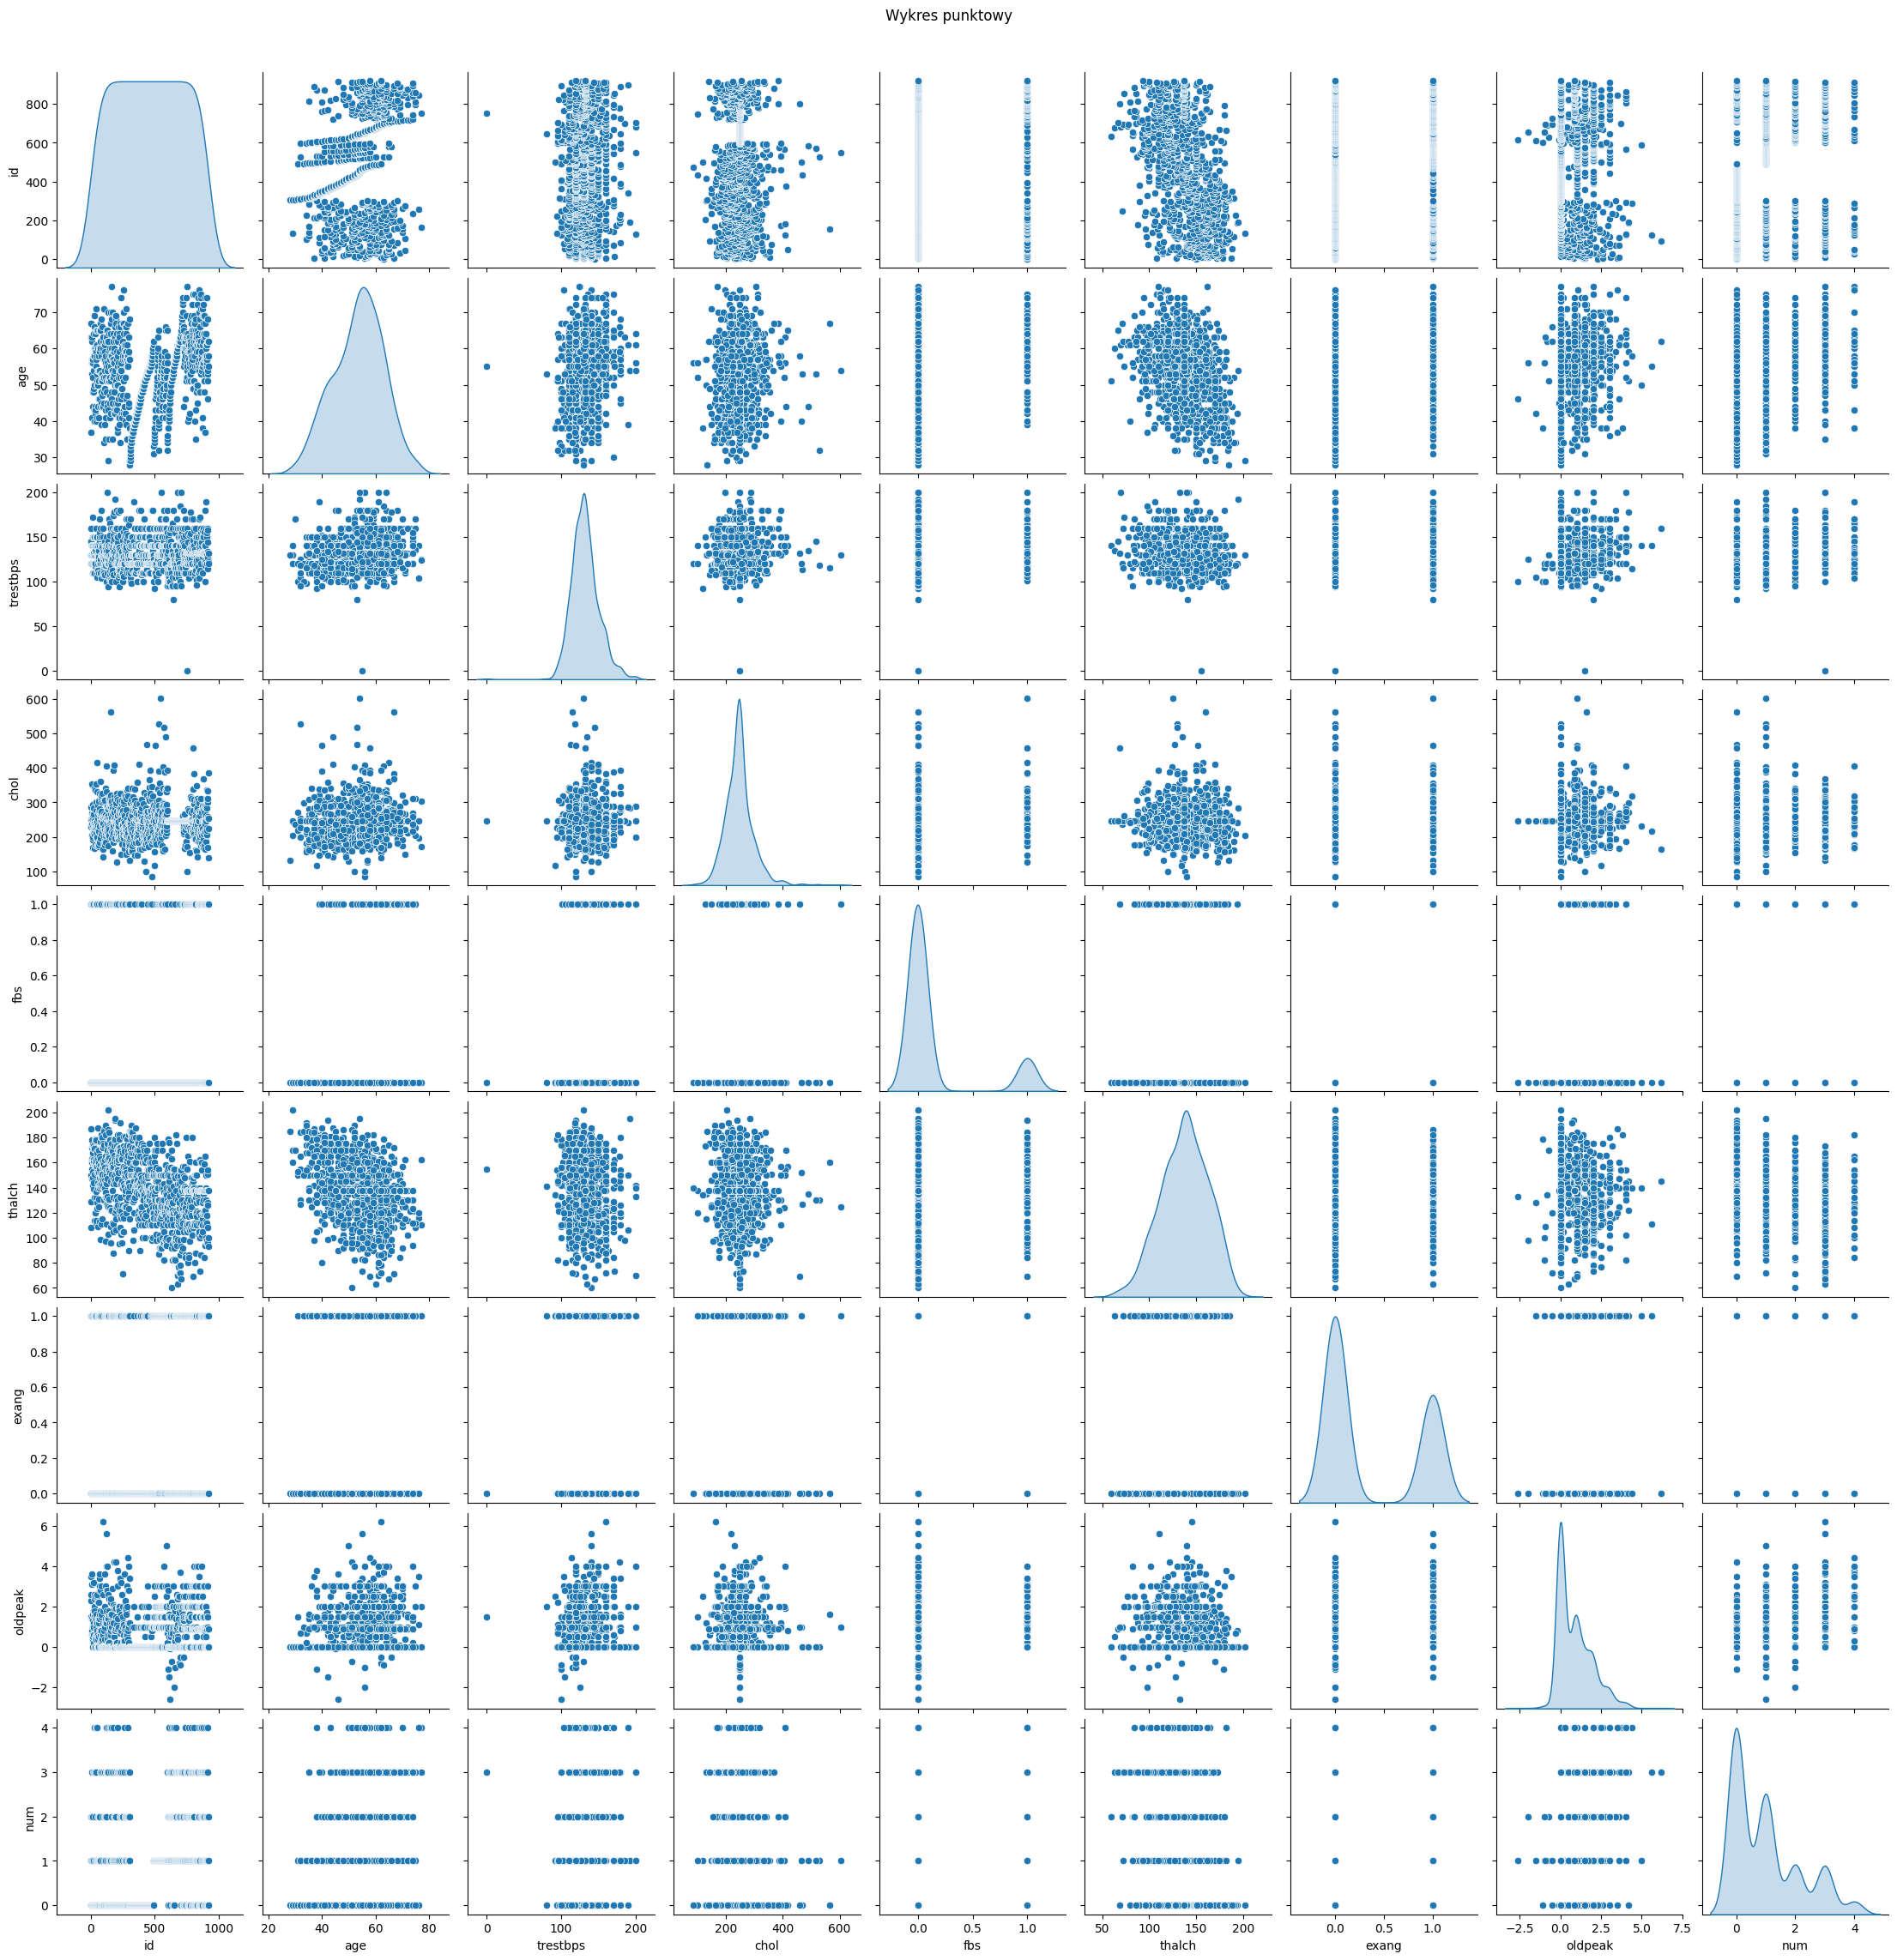

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    float64
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    object 
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    object 
 13  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


,id,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,246.832869,137.545665,0.878788,0.995652
std,265.725422,9.424685,18.443895,51.696191,25.138494,1.053774,1.142693
min,1.000000,28.000000,0.000000,85.000000,60.000000,-2.600000,0.000000
25%,230.750000,47.000000,120.000000,217.750000,120.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,246.832869,138.000000,0.800000,1.000000
75%,690.250000,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [46]:
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer

data = data.drop('ca', axis=1)
data = data.drop('thal', axis=1)
categorical_columns = [col for col in categorical_columns if col not in ['ca', 'thal']]

numeric_imputer = SimpleImputer(strategy = "mean")
categorical_imputer = SimpleImputer(strategy = "most_frequent")

data[numeric_columns] = numeric_imputer.fit_transform(data[numeric_columns])
data[categorical_columns] = categorical_imputer.fit_transform(data[categorical_columns])

sns.pairplot(data, diag_kind = "kde")
plt.suptitle("Wykres punktowy", y = 1.02)
plt.show()    

data.info()
data.describe()

Zakodowanie zmiennych za pomocą LabelEncoder

In [47]:
from sklearn.preprocessing import LabelEncoder

for column in categorical_columns:
    if column not in "thal":
        data[column] = LabelEncoder().fit_transform(data[column])

data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
0,1,63.0,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0
1,2,67.0,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,2
2,3,67.0,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,1
3,4,37.0,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0
4,5,41.0,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0


Wyznaczenie wartości odstających

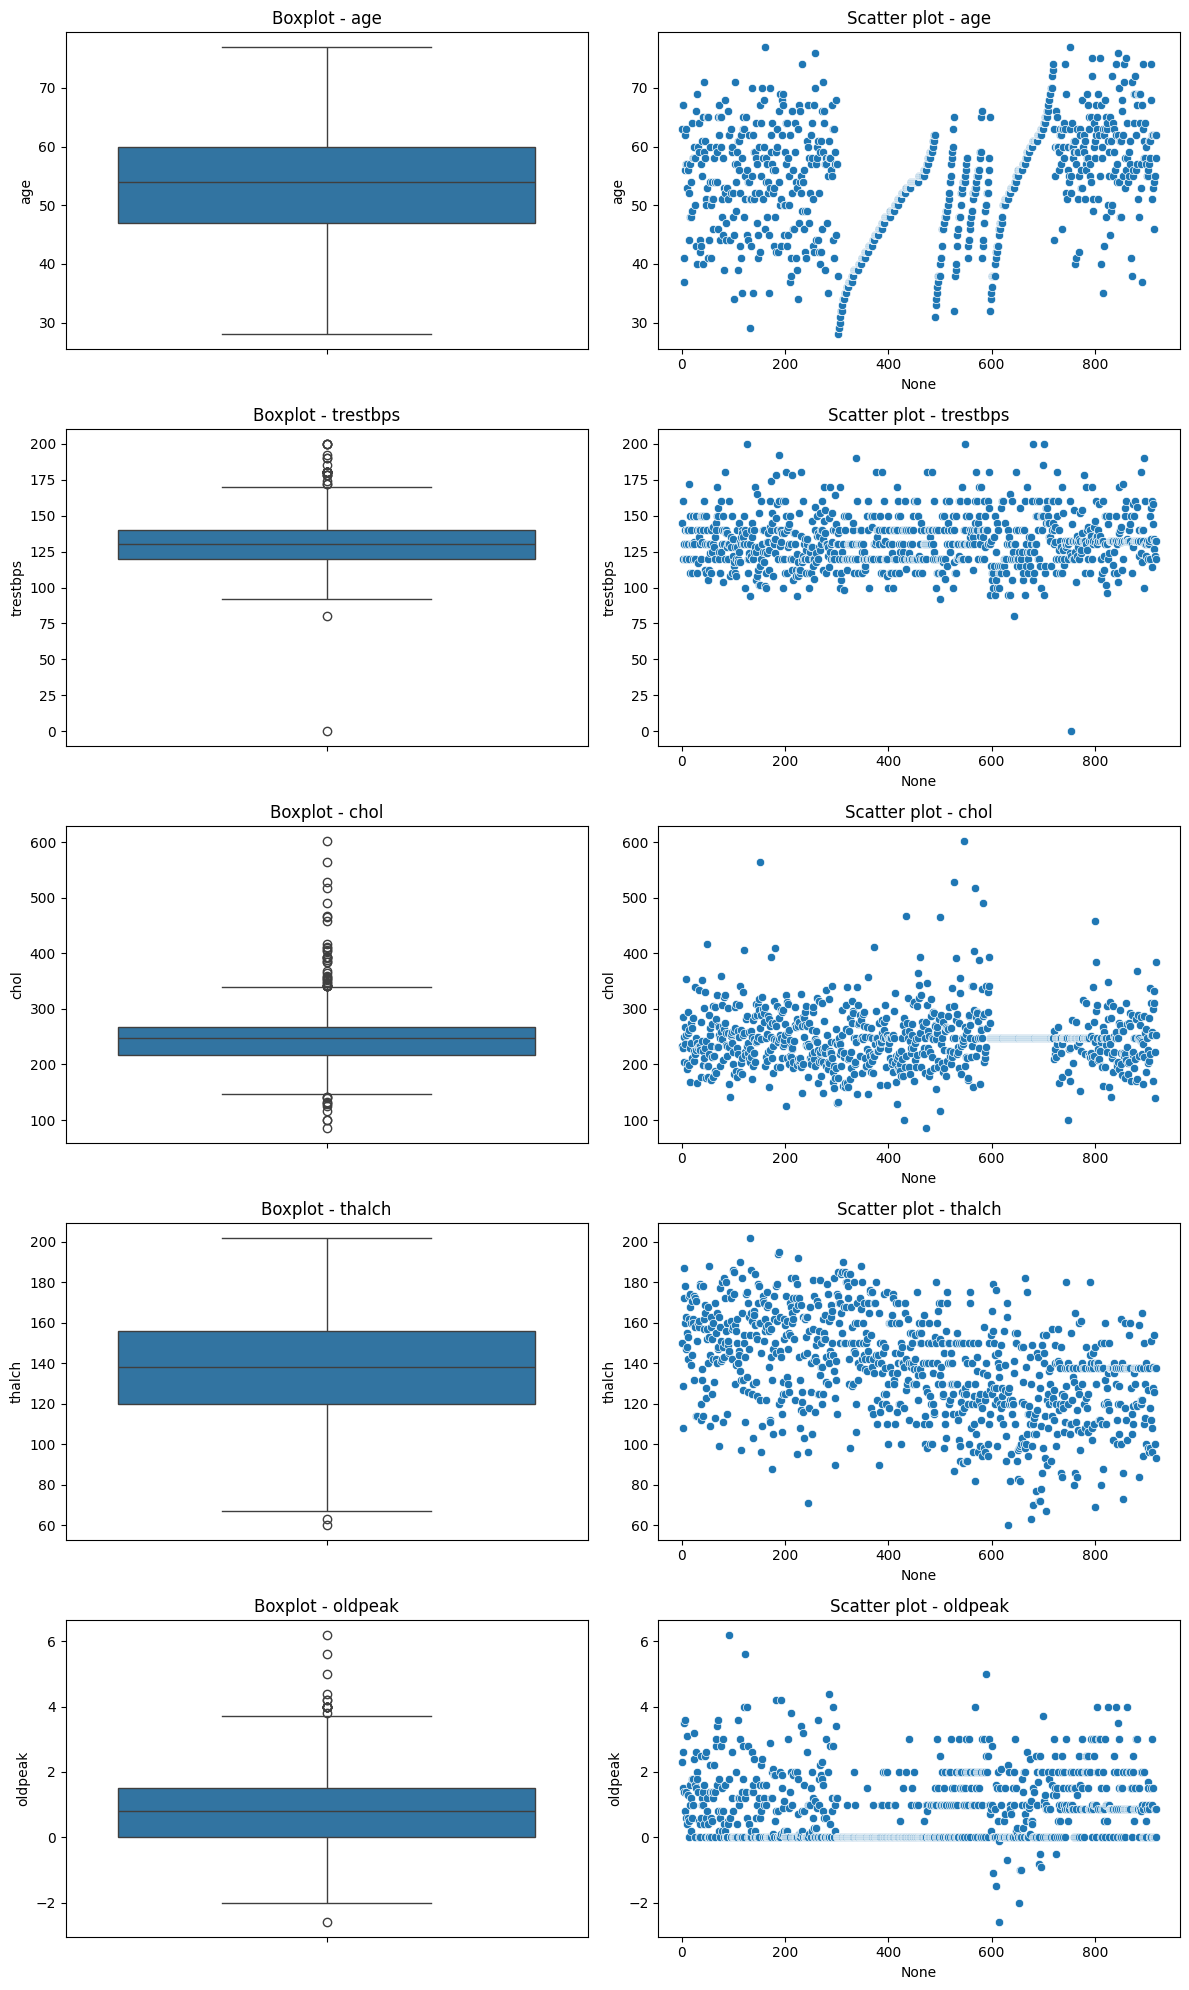

In [10]:
def draw_outliers(df):
    columns = [col for col in df.columns if col not in categorical_columns and col != "id" and col != target_column]
    fig, ax = plt.subplots(len(columns), 2, figsize=(12, 4 * len(columns)))
    for i, column in enumerate(columns):
        sns.boxplot(y=df[column], ax=ax[i, 0])
        ax[i, 0].set_title(f'Boxplot - {column}')
    
        sns.scatterplot(
            x=df.index,
            y=df[column],
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f'Scatter plot - {column}')
    plt.tight_layout()
    plt.show()

draw_outliers(data)

In [15]:
def iqr(df):
    columns = [col for col in df.columns if col not in categorical_columns and col != "id" and col != target_column]
    for i, column in enumerate(columns):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[column] < Q1 - 1.5*IQR) | 
                            (df[column] > Q3 + 1.5*IQR)]
        print(f"Column: {column}\n {outliers}\n\n")

iqr(data)

Column: age
 Empty DataFrame
Columns: [id, age, sex, dataset, cp, trestbps, chol, fbs, restecg, thalch, exang, oldpeak, slope, num]
Index: []


Column: trestbps
       id   age  sex  dataset  cp  trestbps        chol  fbs  restecg  thalch  \
14    15  52.0    1        0   2     172.0  199.000000    1        1   162.0   
83    84  68.0    1        0   2     180.0  274.000000    1        0   150.0   
126  127  56.0    0        0   0     200.0  288.000000    1        0   133.0   
172  173  59.0    0        0   0     174.0  249.000000    0        1   143.0   
183  184  59.0    1        0   3     178.0  270.000000    0        0   145.0   
188  189  54.0    1        0   1     192.0  283.000000    0        0   195.0   
201  202  64.0    0        0   0     180.0  325.000000    0        1   154.0   
213  214  66.0    0        0   0     178.0  228.000000    1        1   165.0   
231  232  55.0    0        0   0     180.0  327.000000    0        2   117.0   
338  339  39.0    1        1   1     1

In [16]:
from scipy import stats
import numpy as np

ids_to_remove = set() 

def z_score(df):  
    columns = [col for col in df.columns if col not in categorical_columns and col != "id" and col != target_column]
    for column in columns:
        zsc = stats.zscore(df[column])
        mask = np.abs(zsc) >= 3
        outliers = df.loc[mask, column].tolist()
        outlier_ids = df.loc[mask, 'id'].tolist()
        ids_to_remove.update(outlier_ids)
        print(
            f"Column: {column}\n"
            f"Outliers: {outliers}\n"
            f"Indexes: {outlier_ids}\n"
            f"Count: {len(outliers)}\n\n"
        )

z_score(data)

Column: age
Outliers: []
Indexes: []
Count: 0


Column: trestbps
Outliers: [200.0, 192.0, 190.0, 200.0, 200.0, 200.0, 0.0, 190.0]
Indexes: [127, 189, 339, 549, 681, 702, 754, 897]
Count: 8


Column: chol
Outliers: [417.0, 407.0, 564.0, 409.0, 412.0, 468.0, 85.0, 466.0, 529.0, 603.0, 404.0, 518.0, 491.0, 458.0]
Indexes: [49, 122, 153, 182, 374, 435, 474, 501, 529, 547, 567, 569, 585, 801]
Count: 14


Column: thalch
Outliers: [60.0]
Indexes: [632]
Count: 1


Column: oldpeak
Outliers: [6.2, 5.6, 4.2, 4.2, 4.4, 5.0, -2.6]
Indexes: [92, 124, 184, 192, 286, 590, 616]
Count: 7




Po analizie uzyskanych wyników zdecydowałam się usunąć rekordy, w których znalazły się odstające wartości w kolumnach: thalch, chol, trestbps. Należą do nich rekordy o indeksach: 632, 754, 547.
632 - thalch, czyli osiągnięte maksymalne tętno (tutaj 60) jest znacznie niższe od średniej (dla osób w wieku 50 lat wynosi 170 uderzeń na minutę). Ten rekord nie pojawia się we szystkich testach, aczkolwiek mimo wszystko zostanie usunięty.
754 - trestbps, czyli spoczynkowe ciśnienie krwi nie może wynieść 0, oznaczałoby to śmierć. Wartość była liczona, gdy pacjent trafił do szpitala, co jest teoretycznie możliwe, gdyby w tamtym momencie miał zatrzymanie akcji serca i udałoby się go uratować. Inną możliwością jest to, że osobnikowi przy przyjęciu nie zmierzono ciśnienia i wpisano daną wartość. Niemniej jednak ten przypadek zostanie pominięty w trakcie tych badań.
547 - chol, czyli cholesterol w surowicy 603 mg/dl to wynik ekstremalnie wysoki.

In [11]:
#odnoszenie się do indeksów kolumny 'id'
data.loc[data['id'].isin([632, 754, 547])]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
546,547,54.0,1,1,0,130.0,603.000000,1,1,125.0,1,1.0,1,1
631,632,51.0,1,2,0,140.0,246.832869,0,1,60.0,0,0.0,1,2
753,754,55.0,1,3,2,0.0,246.832869,0,1,155.0,0,1.5,1,3


In [48]:
data = data.drop([631, 753, 546])

Badanie współliniowości

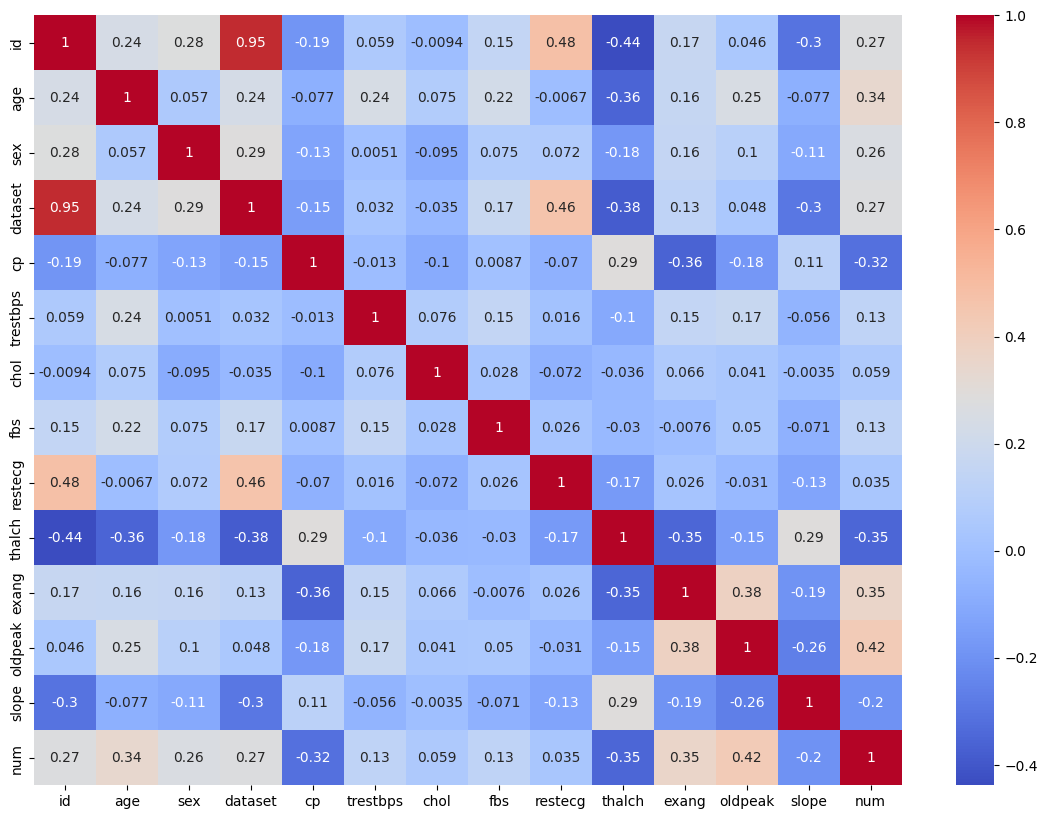

    Variable         VIF
0      const  197.882082
1         id   11.376059
2        age    1.396679
3        sex    1.164754
4    dataset   10.721567
5         cp    1.262800
6   trestbps    1.114751
7       chol    1.044069
8        fbs    1.106001
9    restecg    1.348890
10    thalch    1.608921
11     exang    1.440808
12   oldpeak    1.446121
13     slope    1.234366
14       num    1.582012


In [49]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def draw_heatmap(df):
    num_vars = df.select_dtypes(include=np.number)
    corr = num_vars.corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.show()
    
    X = sm.add_constant(num_vars)
    vif = pd.DataFrame()
    vif['Variable'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif)

draw_heatmap(data)

Wykres cieplny wykazał silną współliniowość między id a dataset. Id nie jest brane pod uwagę, więc nie następują żadne zmiany.

Ze względu na to, że porównujemy wiele grup oraz dane nie mają rozkładu normalnego używamy testu Kruskala-Wallisa.



age             H=116.544  p=0.00000


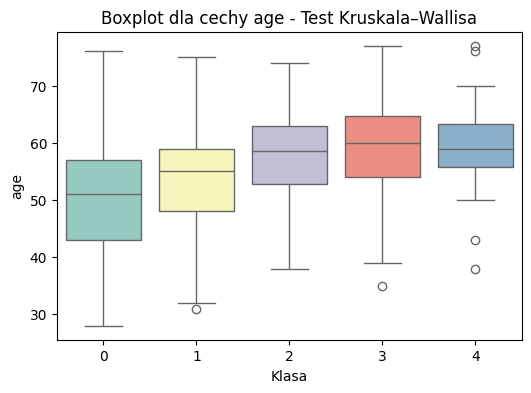



sex             H=86.785  p=0.00000


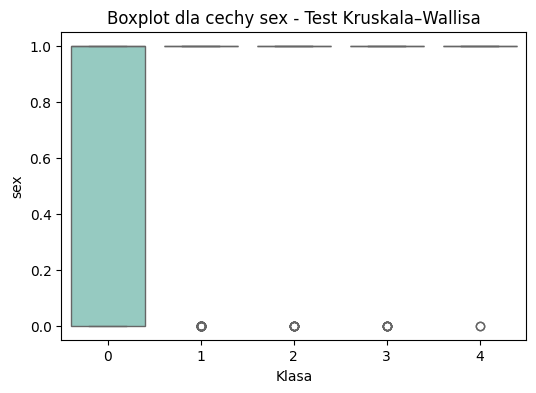



dataset         H=76.187  p=0.00000


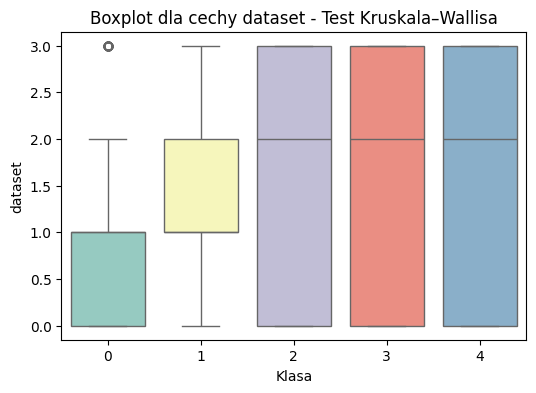



cp              H=179.938  p=0.00000


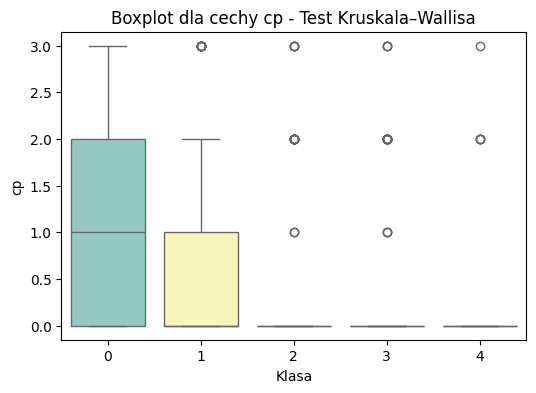



trestbps        H=16.589  p=0.00232


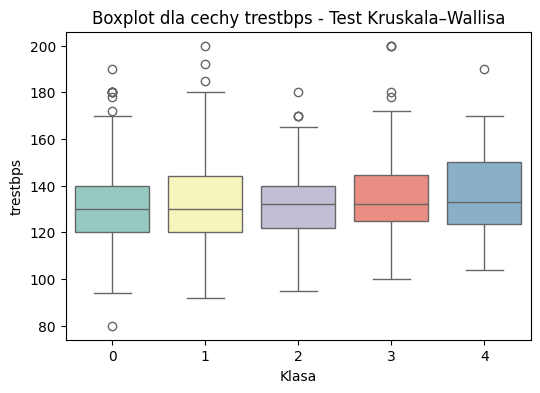



chol            H=16.839  p=0.00208


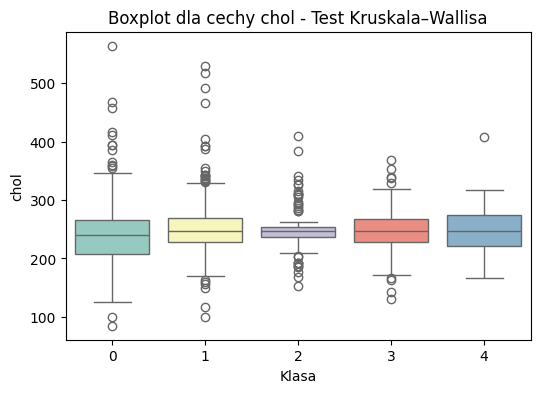



fbs             H=18.713  p=0.00089


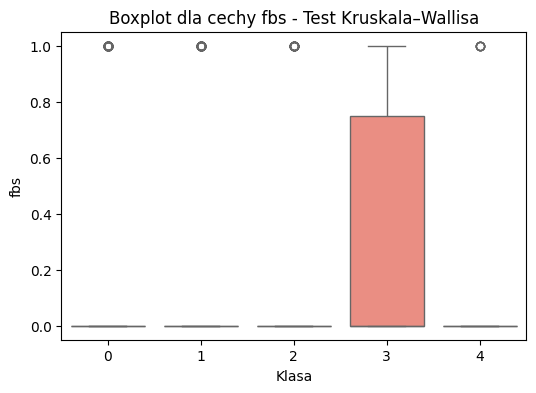



restecg         H=8.629  p=0.07106


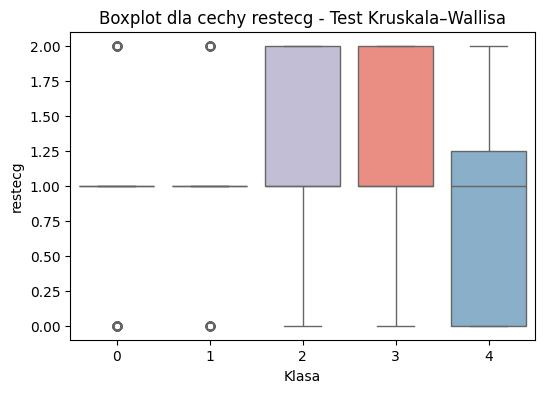



thalch          H=145.005  p=0.00000


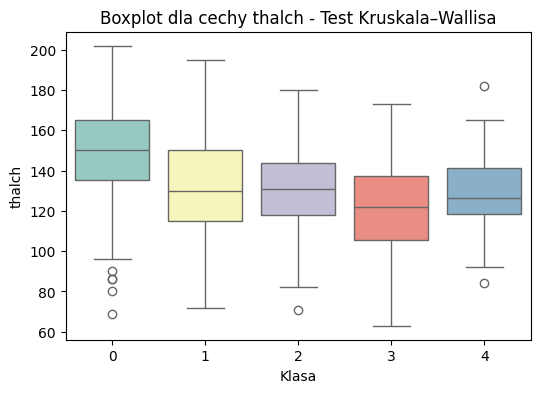



exang           H=174.764  p=0.00000


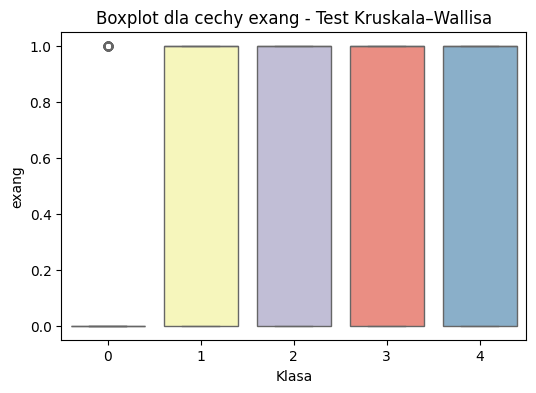



oldpeak         H=166.942  p=0.00000


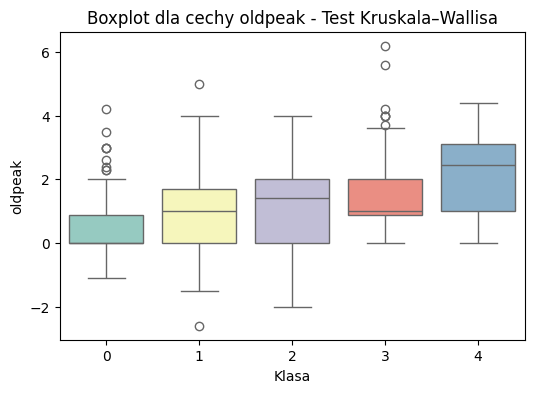



slope           H=42.739  p=0.00000


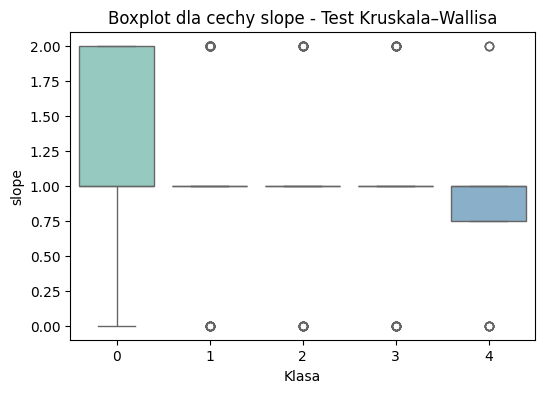

In [50]:
from scipy import stats

def kruskal_all_features(df):
    y = df['num']
    X = df.drop(columns=['num', 'id'])

    for feature in X.columns:
        groups = [X.loc[y == cls, feature] for cls in y.unique()]
        H, p = stats.kruskal(*groups)
        print(f"\n\n{feature:15s} H={H:.3f}  p={p:.5f}")
        plt.figure(figsize=(6,4))
        sns.boxplot(x=y, y=X[feature], hue=y, legend=False, palette='Set3')
        plt.title(f"Boxplot dla cechy {feature} - Test Kruskala–Wallisa")
        plt.xlabel('Klasa')
        plt.ylabel(feature)
        plt.show()

kruskal_all_features(data)

Z testu wynika, że jest brak różnic istotnych statystycznie dla restecg, którego p=0.07106 > 0.05

In [51]:
data = data.drop('restecg', axis=1)
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,thalch,exang,oldpeak,slope,num
0,1,63.0,1,0,3,145.0,233.0,1,150.0,0,2.3,0,0
1,2,67.0,1,0,0,160.0,286.0,0,108.0,1,1.5,1,2
2,3,67.0,1,0,0,120.0,229.0,0,129.0,1,2.6,1,1
3,4,37.0,1,0,2,130.0,250.0,0,187.0,0,3.5,0,0
4,5,41.0,0,0,1,130.0,204.0,0,172.0,0,1.4,2,0


In [18]:
data.value_counts("num")

num
0    411
1    264
2    108
3    106
4     28
Name: count, dtype: int64

Zapis danych do pliku w celu szybszej analizy w przyszłości.

In [7]:
data.to_csv(r'..\zbiory\data_heart_processed.csv', header=True, index=False, encoding='utf-8')
print("Zapisano plik.")

Zapisano plik.


### Podział zbioru na dane testowe i treningowe

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

data = pd.read_csv(r'..\zbiory_przerobione\data_heart_processed.csv')
y = data['num']
X = data.drop(columns=['num', 'id'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

for column in X_train.columns:      
    standardScaler = StandardScaler().fit(X_train[[column]])
    X_train[column] = standardScaler.transform(X_train[[column]])
    X_test[column] = standardScaler.transform(X_test[[column]])
    
#---------- ustawienie badanej pozycji tablicy
sample_pos = 9
x_sample = X_train.iloc[sample_pos]
true_class = y_train.iloc[sample_pos]
print(f"Klasa, do której należy probka o wskazanej pozycji ({sample_pos}): {true_class}\n{x_sample}")

class_names = ['0', '1', '2', '3', '4']
X_train.head()

Klasa, do której należy probka o wskazanej pozycji (9): 0
age        -2.282871
sex         0.530536
dataset    -0.186510
cp          0.215487
trestbps   -1.219054
chol       -0.422758
fbs        -0.404342
thalch      1.850033
exang      -0.745831
oldpeak    -0.815880
slope      -0.307978
Name: 309, dtype: float64


,age,sex,dataset,cp,trestbps,chol,fbs,thalch,exang,oldpeak,slope
223,-0.020284,0.530536,-1.068523,-0.830554,-0.494761,0.737459,-0.404342,-1.712522,1.340787,1.068484,-0.307978
152,1.488107,-1.884886,-1.068523,1.261529,-0.940480,6.477480,-0.404342,0.889344,-0.745831,0.691611,-0.307978
300,0.410684,0.530536,-1.068523,-0.830554,-0.104758,-2.336098,-0.404342,-0.911948,1.340787,0.314738,-0.307978
691,0.949396,0.530536,0.695503,-0.830554,-0.940480,0.021643,-0.404342,-0.391575,1.340787,1.539575,-2.205020
622,-0.343511,0.530536,0.695503,-0.830554,-0.940480,0.021643,-0.404342,-0.711805,1.340787,-0.344789,-0.307978


### Random Forest - nauka modelu

ROC AUC (OvR): 0.8451979198210292
Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        82
           1       0.54      0.64      0.59        53
           2       0.30      0.27      0.29        22
           3       0.40      0.29      0.33        21
           4       1.00      0.17      0.29         6

    accuracy                           0.62       184
   macro avg       0.61      0.44      0.46       184
weighted avg       0.63      0.62      0.61       184



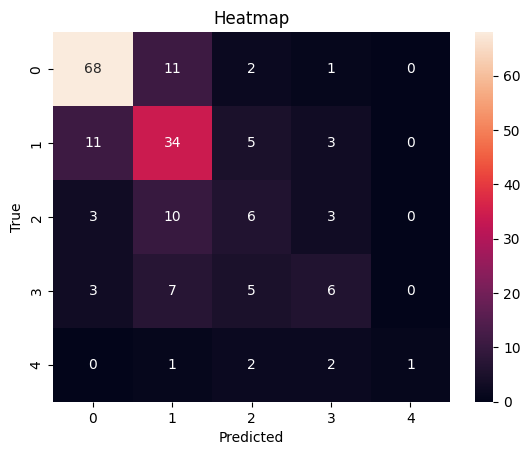

Przewidywanie dla wskazanego id:  [[0.96 0.04 0.   0.   0.  ]]


In [4]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model = train_model(random_forest_model, X_train, y_train, X_test, y_test, sample_pos)

### Random Forest - LIME

C:\Users\savan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


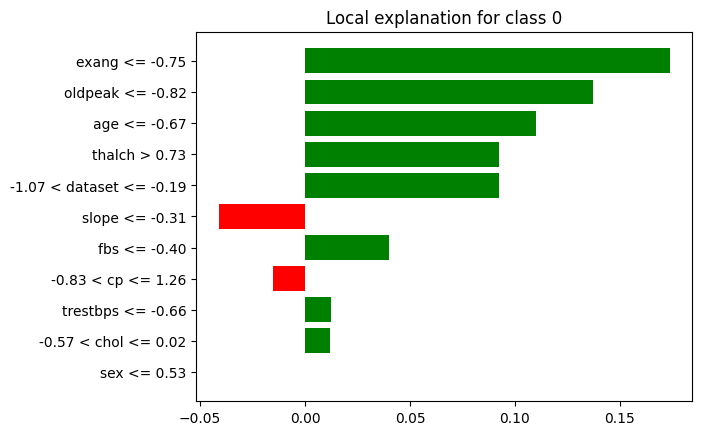

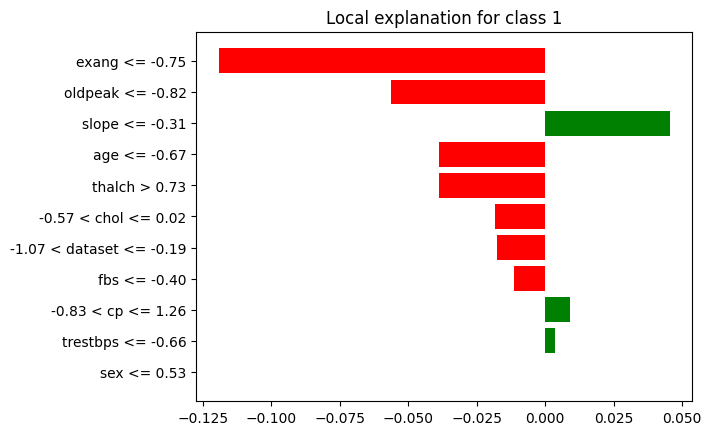

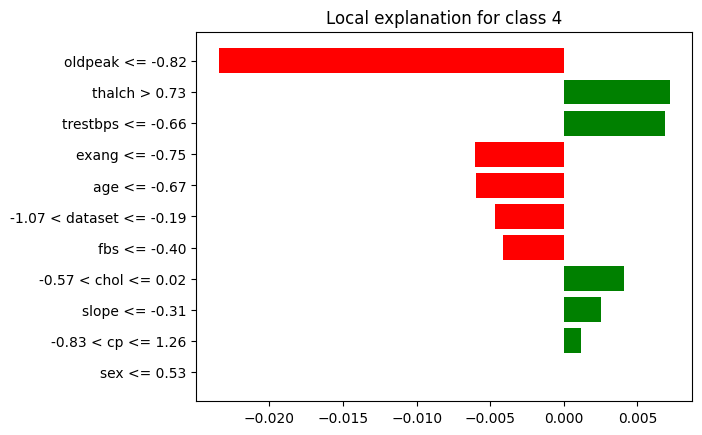

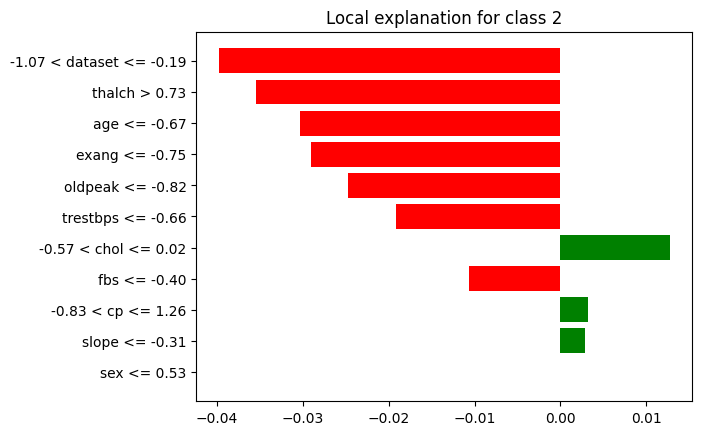

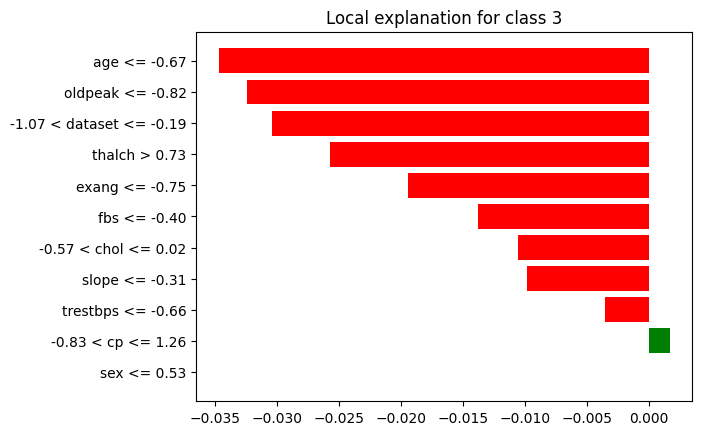




(5, 11, 2)


<Figure size 640x480 with 0 Axes>

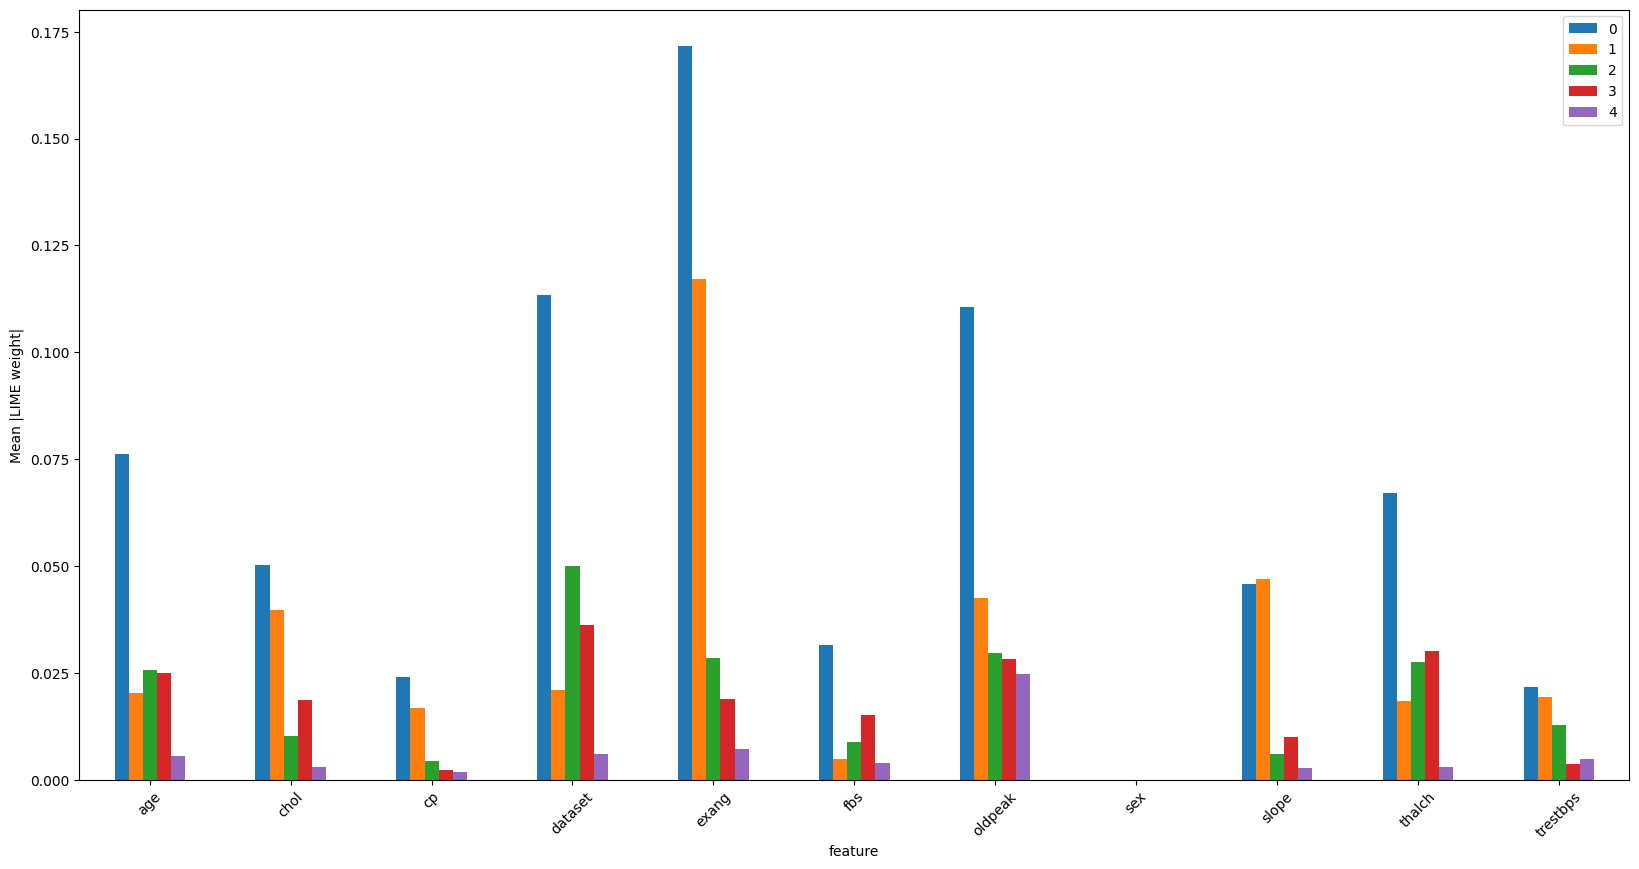

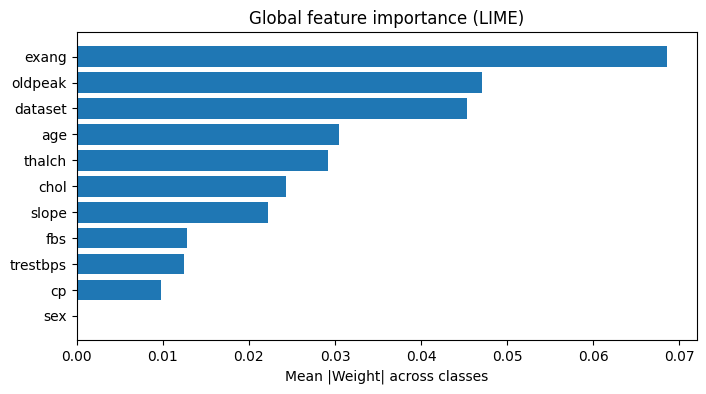

In [5]:
class_names = ['0', '1', '2', '3', '4']
lime(random_forest_model, X_train, class_names, sample_pos)

### Random Forest - SHAP

(733, 11, 5)

Local explanation for class 0


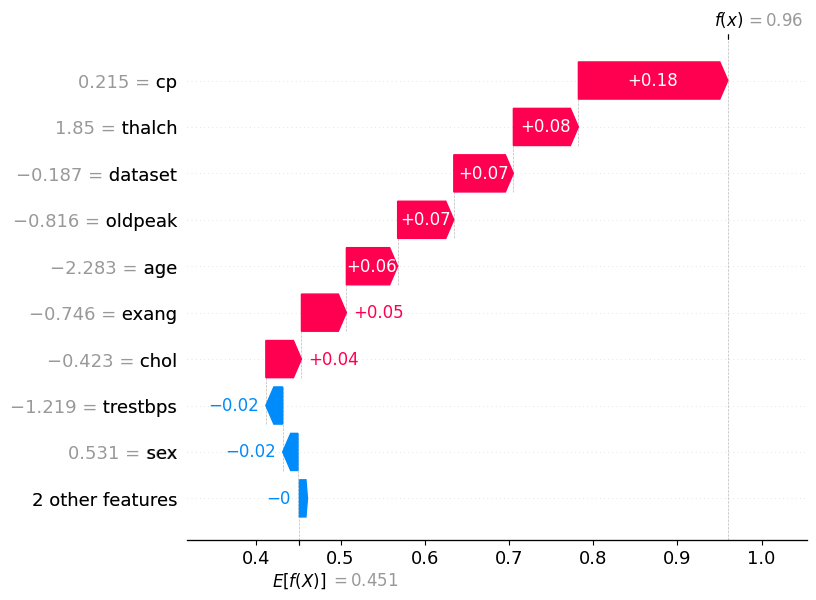


Local explanation for class 1


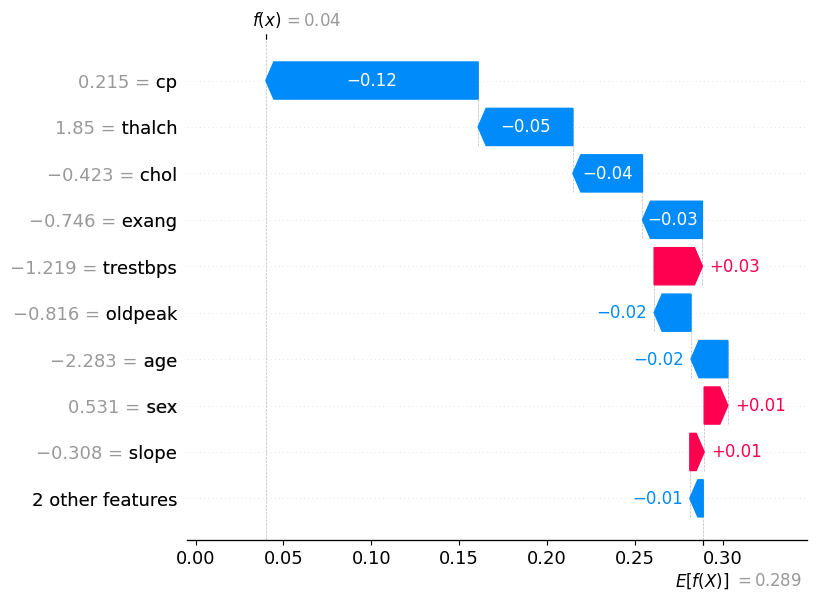


Local explanation for class 2


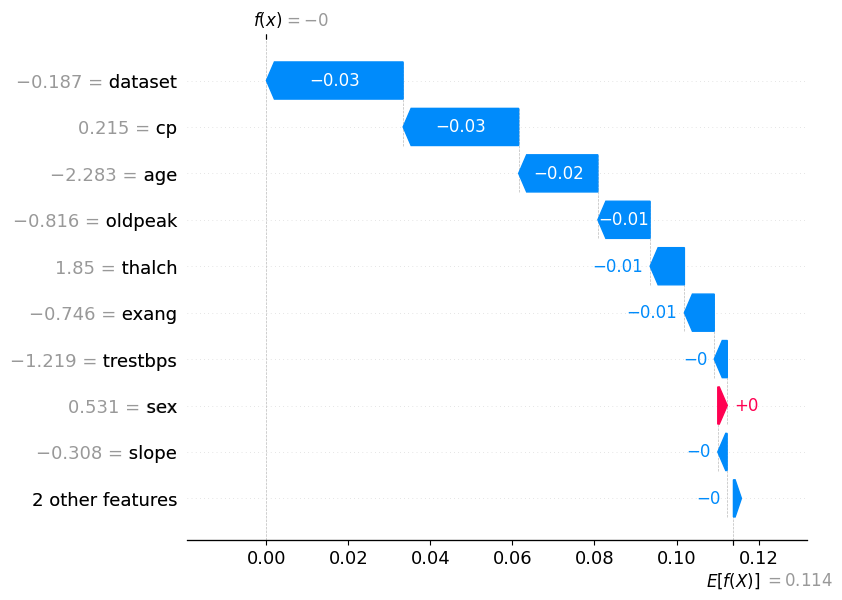


Local explanation for class 3


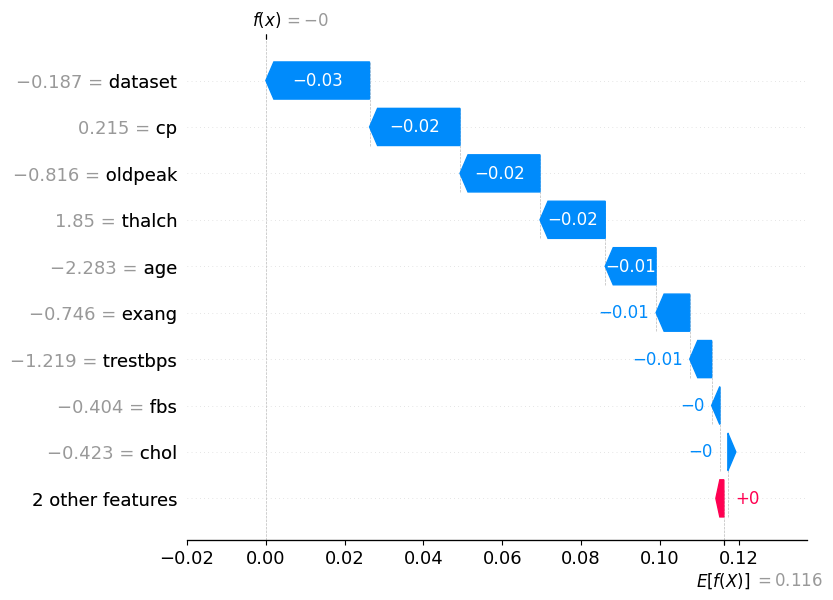


Local explanation for class 4


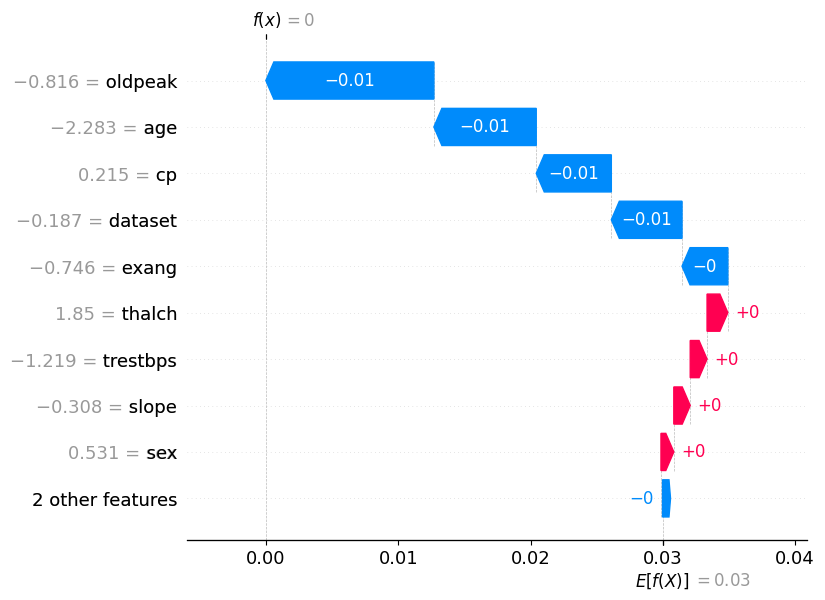

<Figure size 640x480 with 0 Axes>

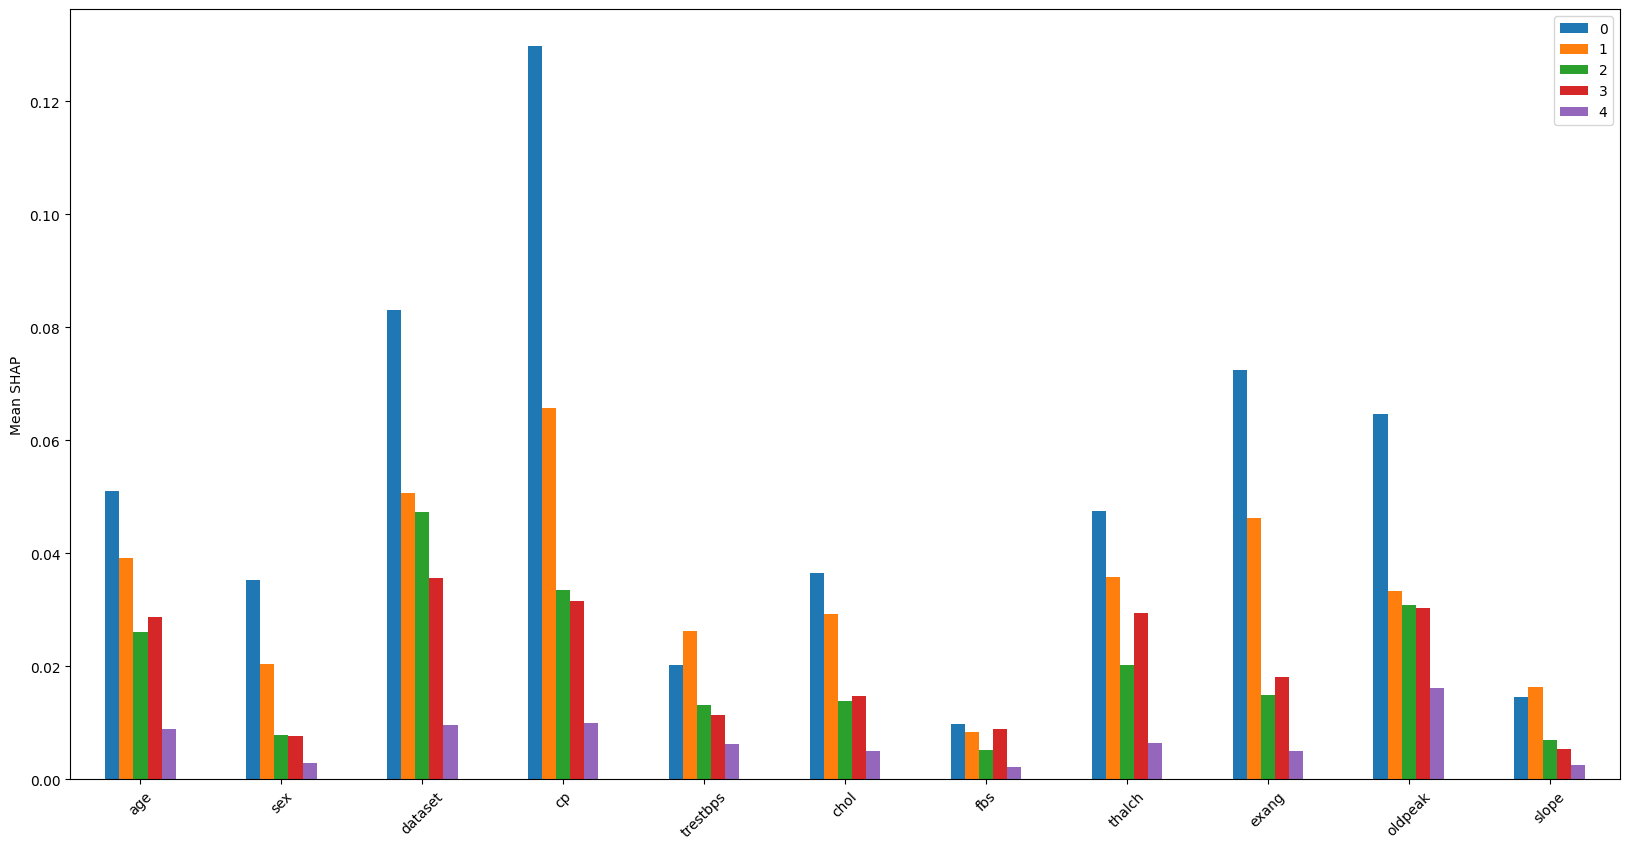

(733, 11)


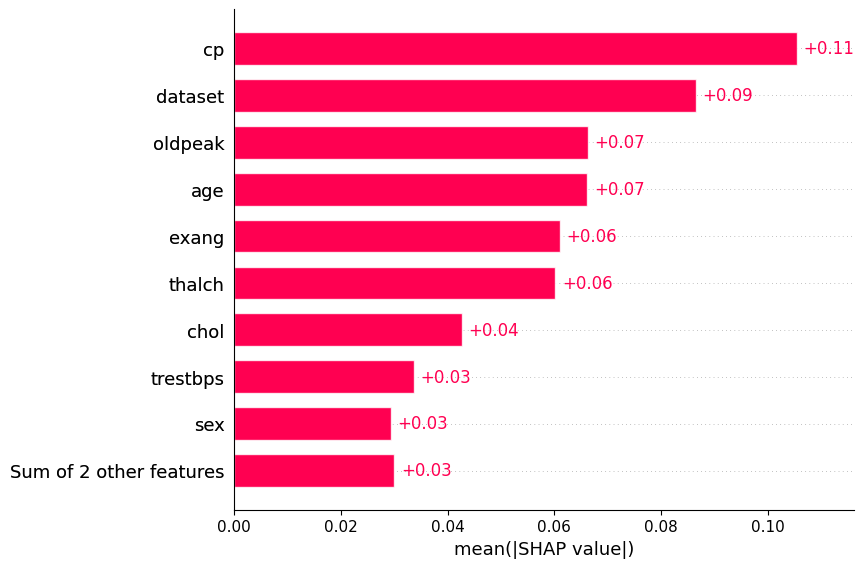

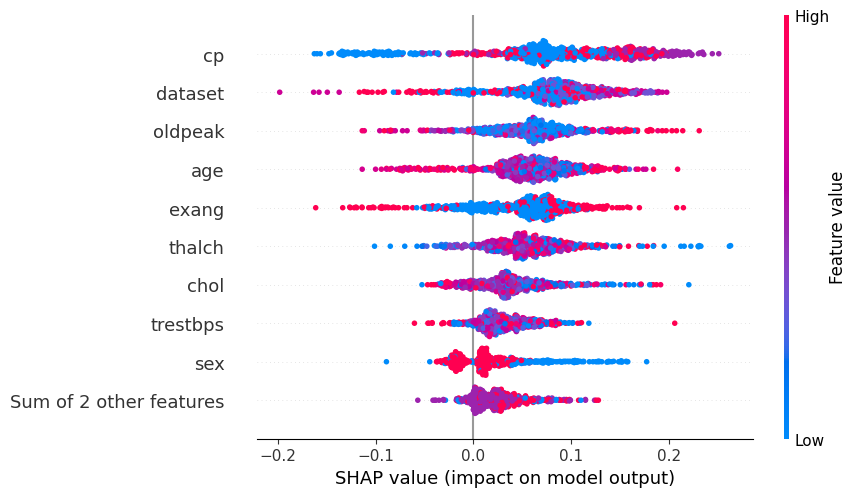

In [6]:
multiclass_shap(random_forest_model, X_train, class_names, sample_pos)

### Random Forest - PFI

dataset 0.175 +/- 0.012
cp      0.175 +/- 0.012
age     0.128 +/- 0.011
oldpeak 0.116 +/- 0.010
thalch  0.090 +/- 0.007
chol    0.071 +/- 0.006
exang   0.069 +/- 0.006
trestbps0.049 +/- 0.005
sex     0.026 +/- 0.005
fbs     0.015 +/- 0.002
slope   0.005 +/- 0.002


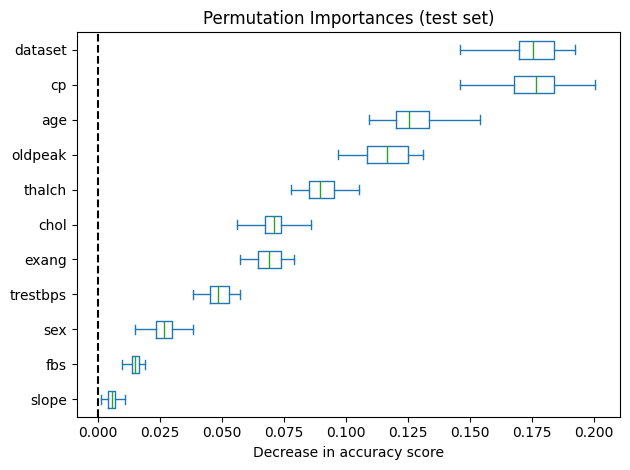

In [13]:
pfi(random_forest_model, X_train, y_train)

### XGBoost - nauka modelu

ROC AUC (OvR): 0.8391360223433109
Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        82
           1       0.56      0.62      0.59        53
           2       0.37      0.32      0.34        22
           3       0.43      0.43      0.43        21
           4       1.00      0.17      0.29         6

    accuracy                           0.64       184
   macro avg       0.63      0.47      0.49       184
weighted avg       0.64      0.64      0.63       184



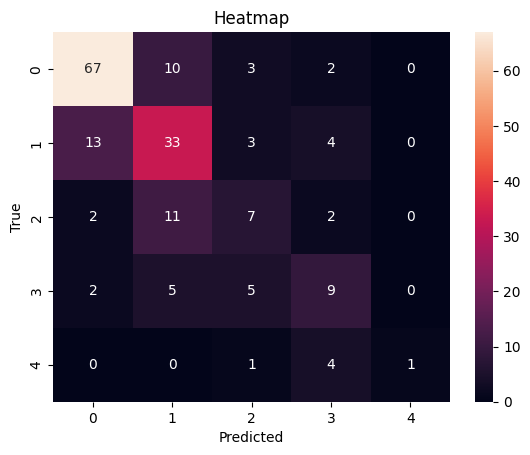

Przewidywanie dla wskazanego id:  [[0.9987 0.0012 0.     0.     0.    ]]


In [6]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42, subsample=0.8, colsample_bytree=0.8)
xgb_model = train_model(xgb_model, X_train, y_train, X_test, y_test, sample_pos)

### XGBoost - LIME

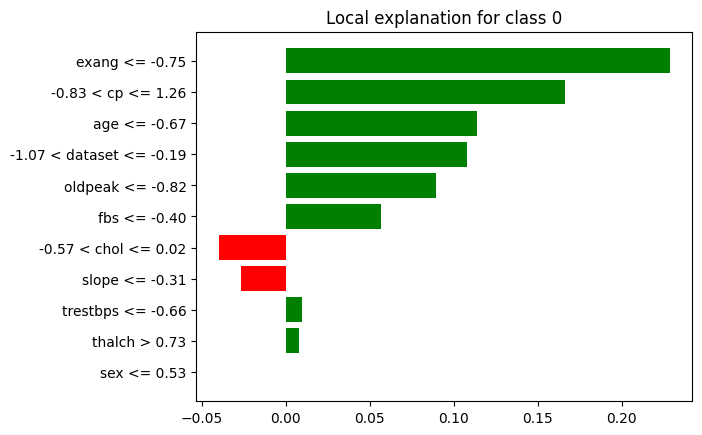

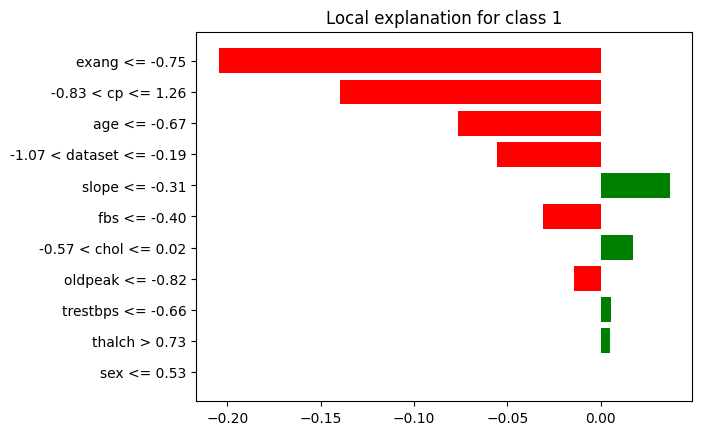

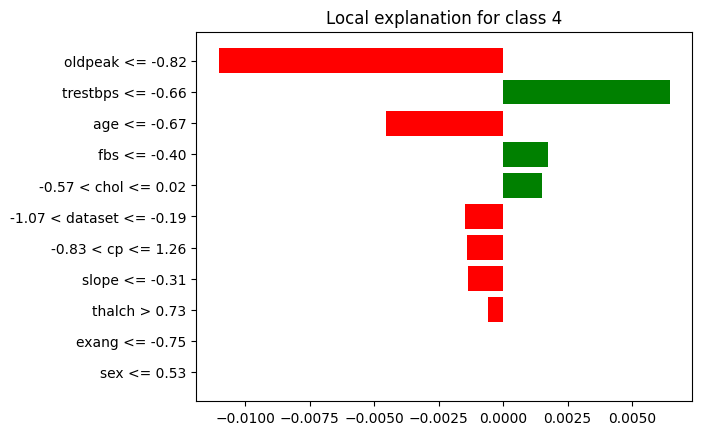

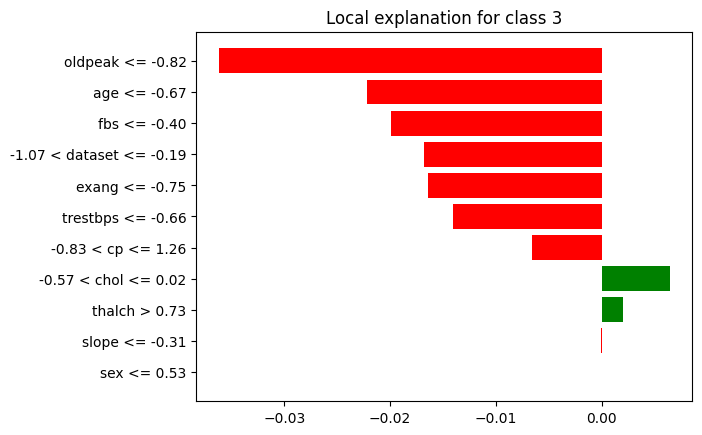

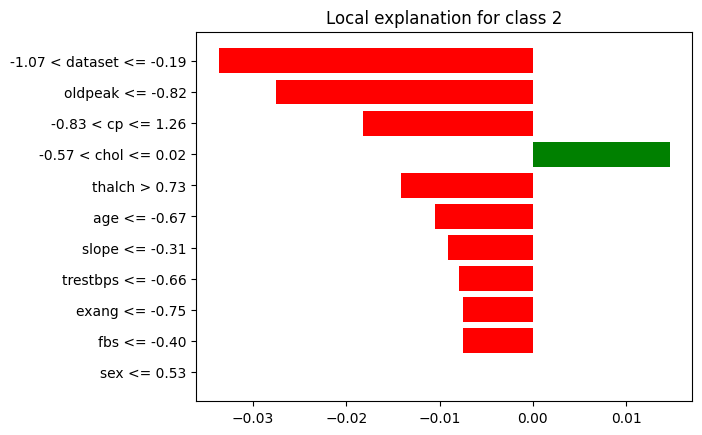




(5, 11, 2)


<Figure size 640x480 with 0 Axes>

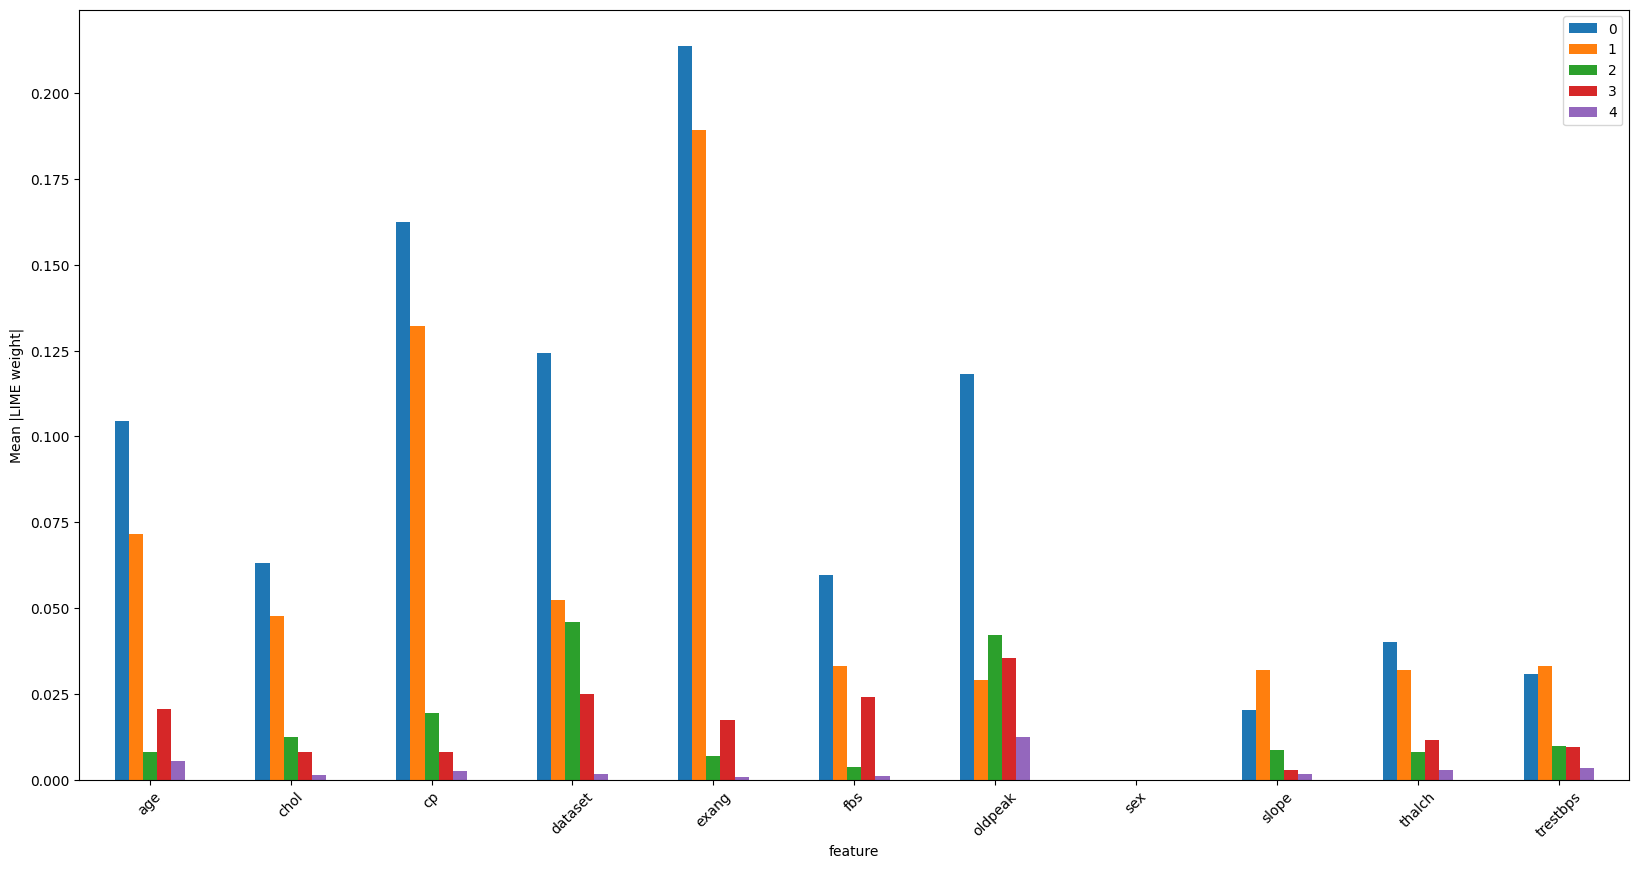

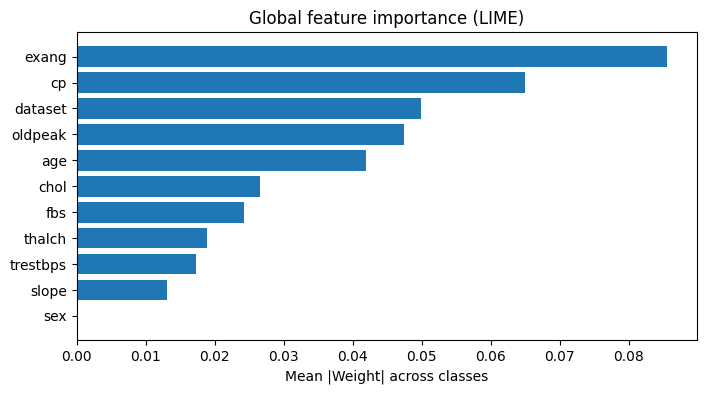

In [7]:
lime(xgb_model, X_train, class_names, sample_pos)

### XGBoost - SHAP

(733, 11, 5)

Local explanation for class 0


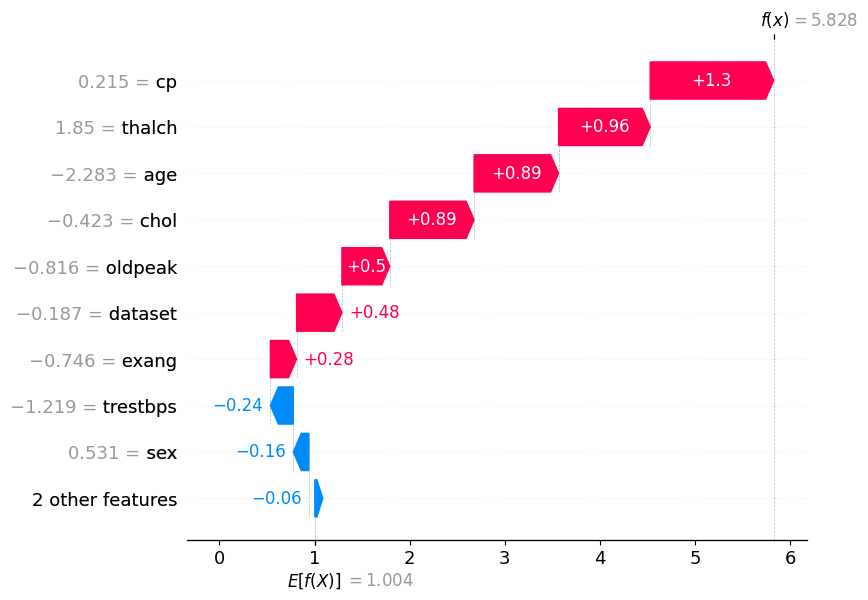


Local explanation for class 1


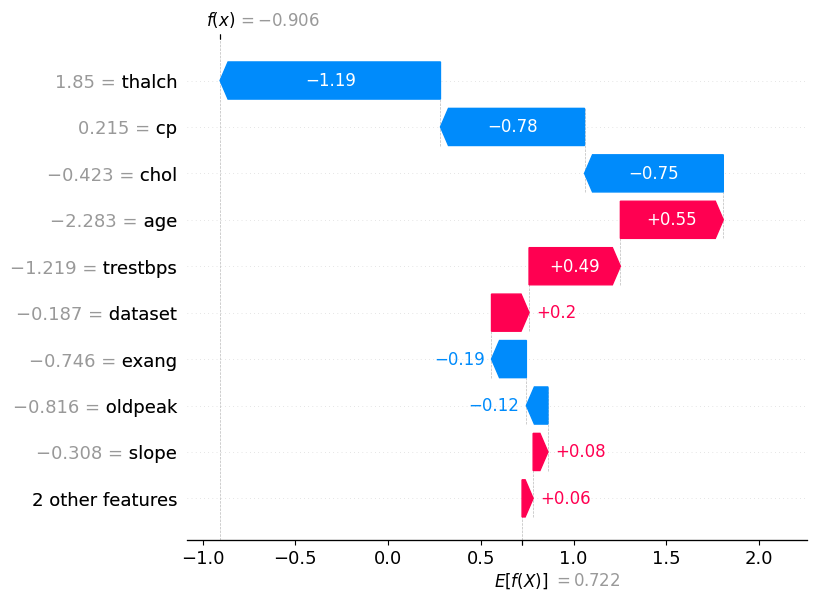


Local explanation for class 2


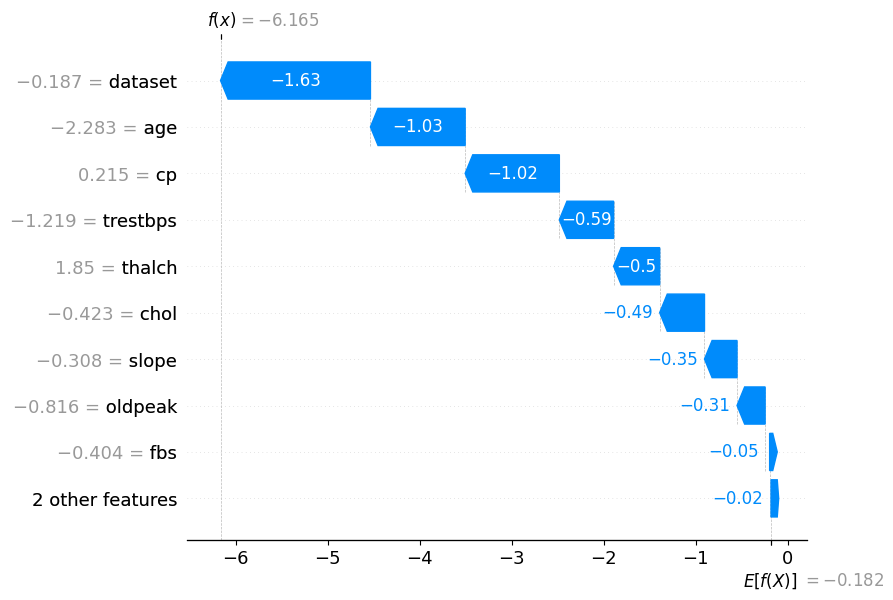


Local explanation for class 3


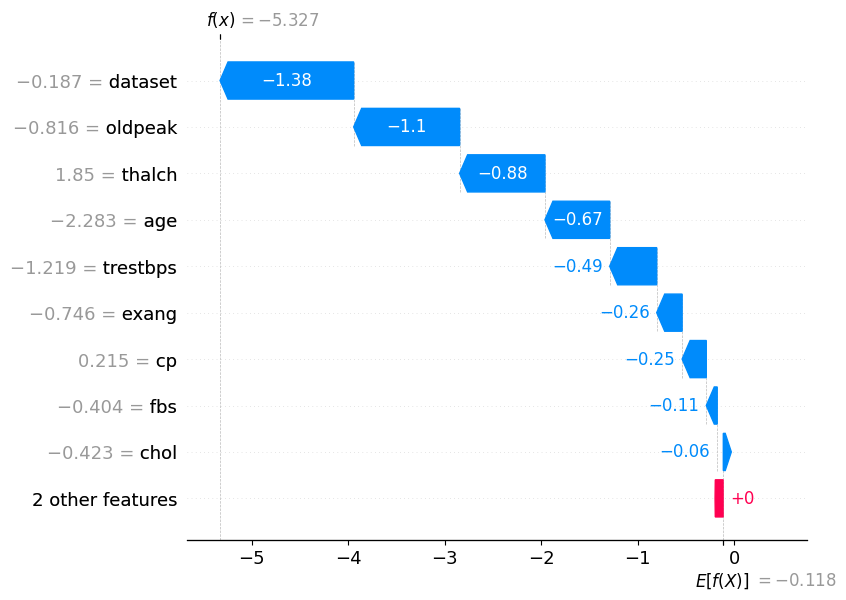


Local explanation for class 4


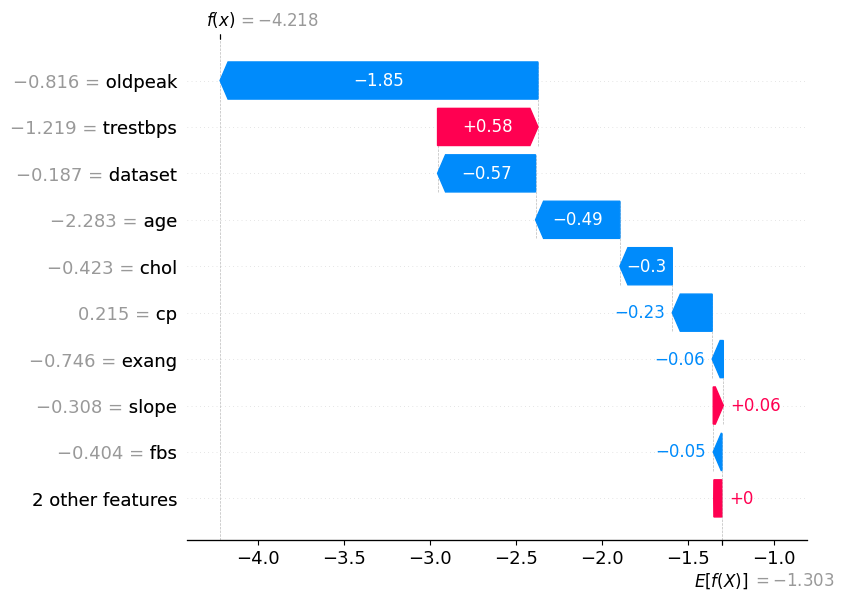

<Figure size 640x480 with 0 Axes>

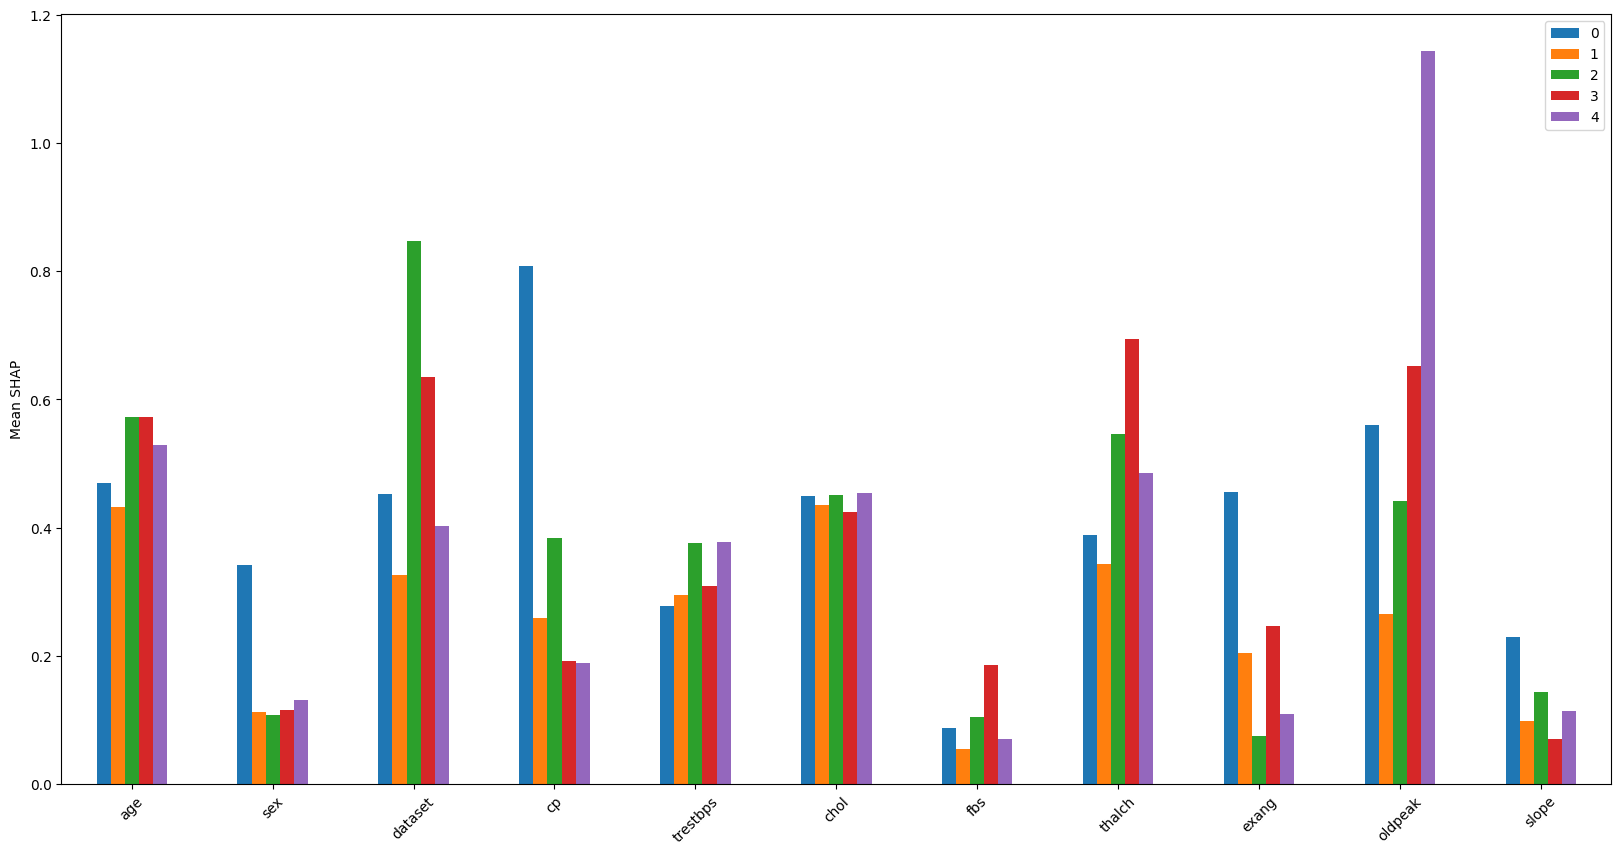

(733, 11)


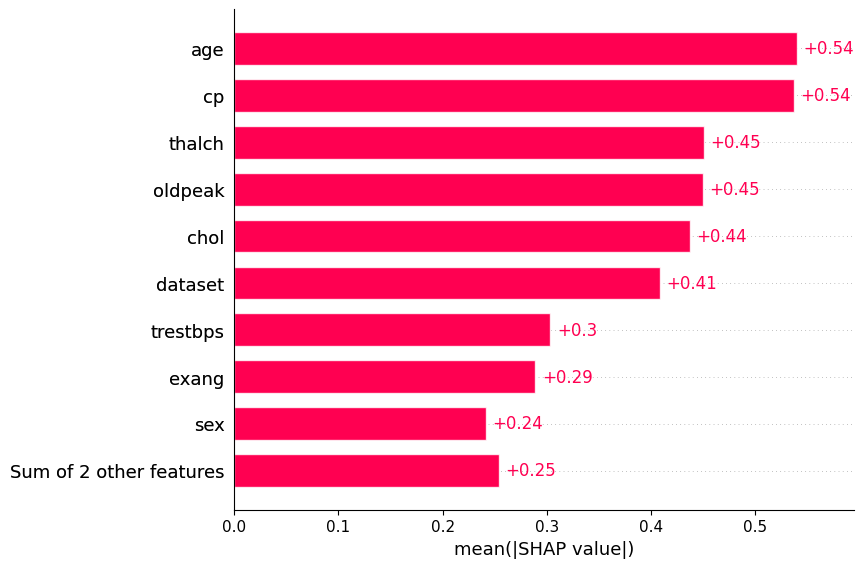

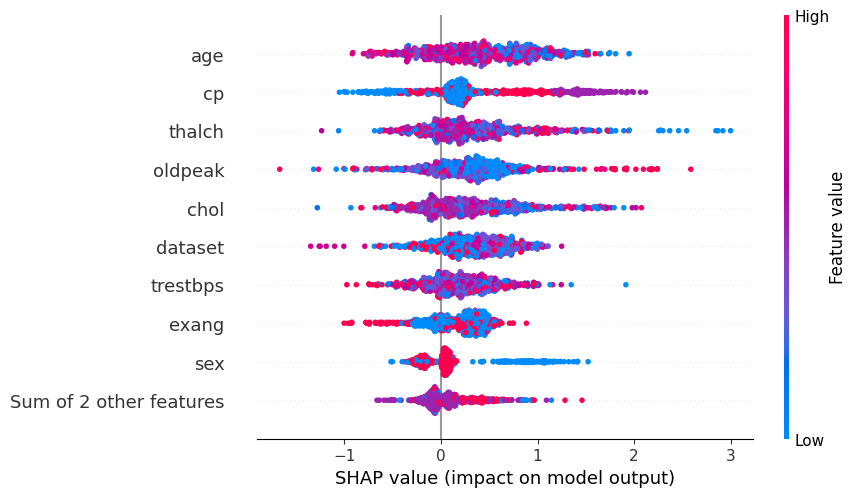

In [8]:
multiclass_shap(xgb_model, X_train, class_names, sample_pos)

### XGBoost - PFI

age     0.150 +/- 0.012
oldpeak 0.127 +/- 0.010
chol    0.126 +/- 0.011
thalch  0.121 +/- 0.008
dataset 0.098 +/- 0.009
trestbps0.072 +/- 0.006
cp      0.063 +/- 0.006
exang   0.013 +/- 0.003
sex     0.013 +/- 0.003
fbs     0.006 +/- 0.002
slope   0.005 +/- 0.001


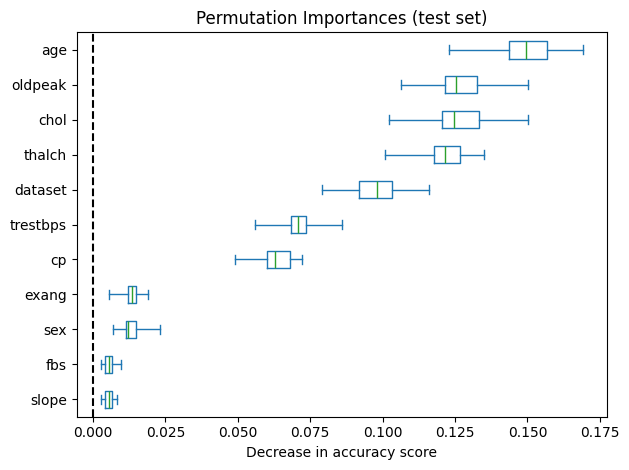

In [18]:
pfi(xgb_model, X_train, y_train)

### Sieć neuronowa - nauka modelu

In [19]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.datasets import make_classification

activations = ["relu", "tanh", "logistic", "identity"]
optimizers  = ["adam", "sgd", "lbfgs"]
architectures = [
    [16, 16],
    [32, 32],
    [64, 64],
    [16, 16, 16],
    [16, 32, 16],
    [32, 32, 32],
    [32, 64, 32],
    [64, 64, 64],
    [64, 128, 64],
    [64, 128, 128],
    [128, 128, 64],
    [128, 128, 128],
    [64, 128, 128, 64],
    [128, 128, 128, 128],
    [64, 128, 64, 128, 64]
]

param_grid = {'activation': activations, 'early_stopping': [True], 'hidden_layer_sizes': architectures, 'solver': optimizers}
mlp_classifier = MLPClassifier(random_state=42)
mlp_classifier_cv = GridSearchCV(mlp_classifier, param_grid, cv=5, n_jobs=2)

mlp_classifier_cv.fit(X_train, y_train)

print("MLPClassifier parameters for best model: {}".format(mlp_classifier_cv.best_params_))
print("Best score is {}".format(mlp_classifier_cv.best_score_))

MLPClassifier parameters for best model: {'activation': 'tanh', 'early_stopping': True, 'hidden_layer_sizes': [64, 128, 128, 64], 'solver': 'adam'}
Best score is 0.572947535178455


ROC AUC (OvR): 0.7953065141672472
Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        82
           1       0.47      0.58      0.52        53
           2       0.21      0.14      0.17        22
           3       0.29      0.29      0.29        21
           4       0.00      0.00      0.00         6

    accuracy                           0.60       184
   macro avg       0.36      0.37      0.37       184
weighted avg       0.57      0.60      0.58       184



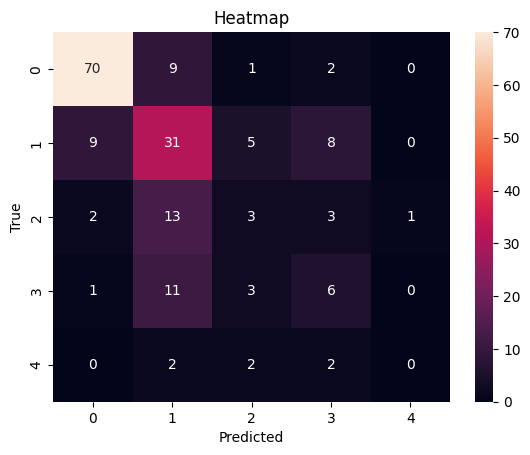

Przewidywanie dla wskazanego id:  [[0.8945 0.0941 0.0054 0.0044 0.0016]]


In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

dnn_model = MLPClassifier(activation='tanh', early_stopping = True, hidden_layer_sizes=(64, 128, 128, 64), solver='adam', random_state=42)
dnn_model = train_model(dnn_model, X_train, y_train, X_test, y_test, sample_pos)

### Sieć neuronowa - LIME

C:\Users\savan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


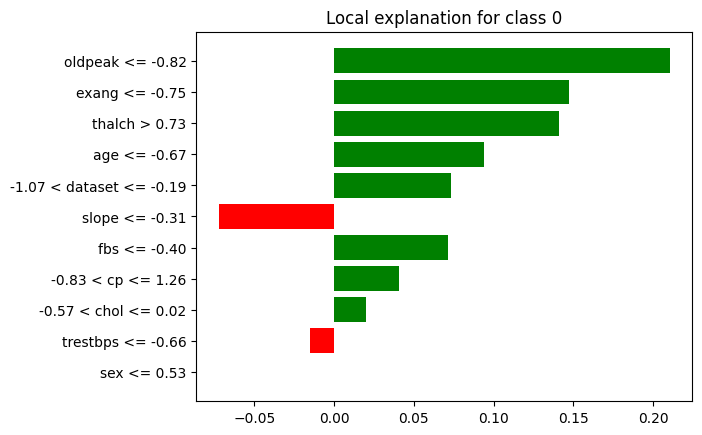

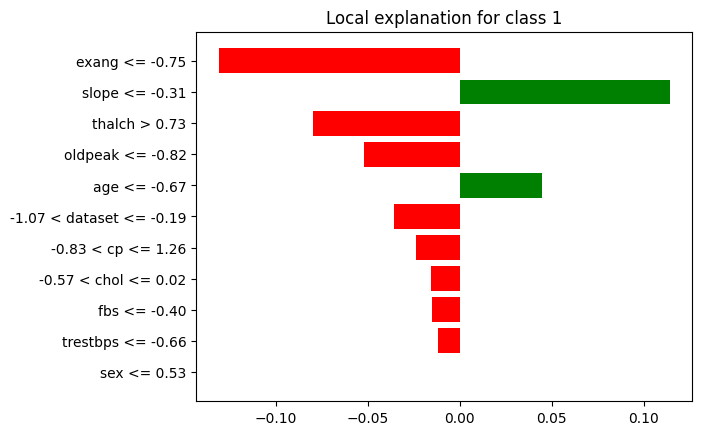

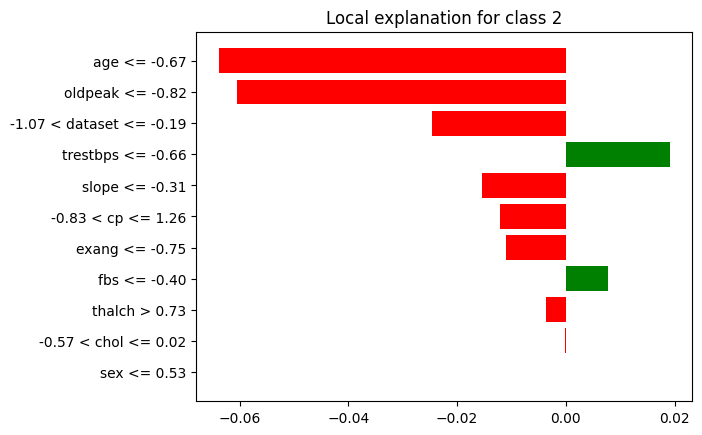

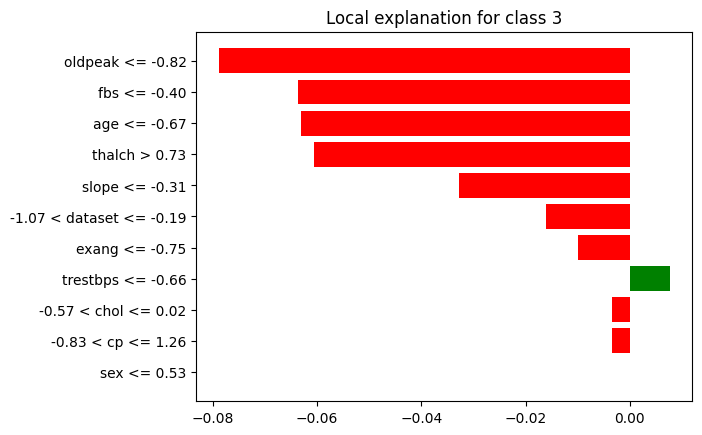

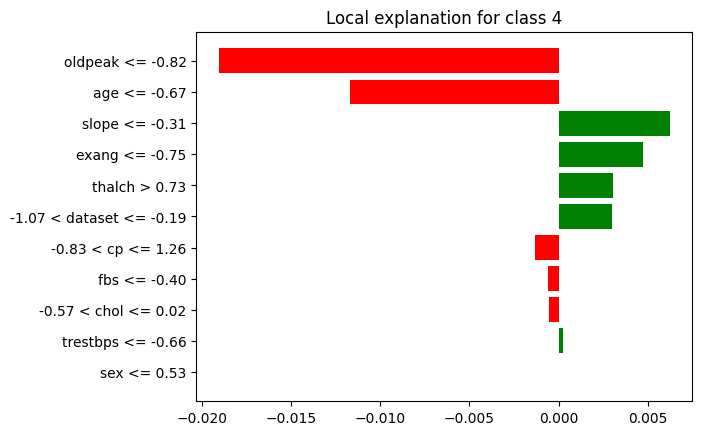




(5, 11, 2)


<Figure size 640x480 with 0 Axes>

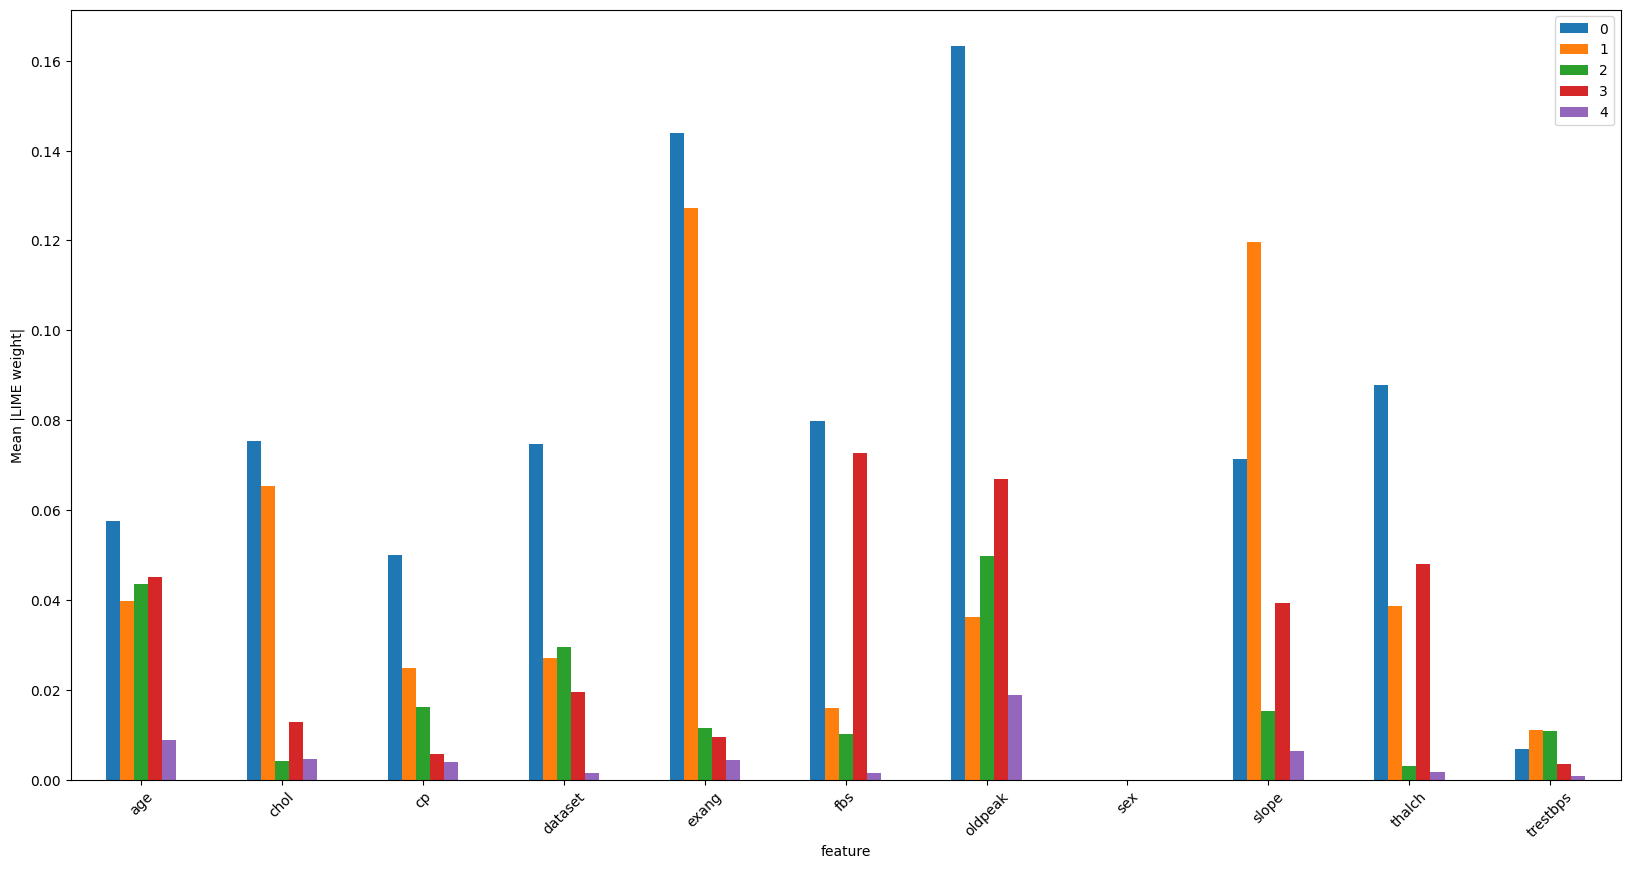

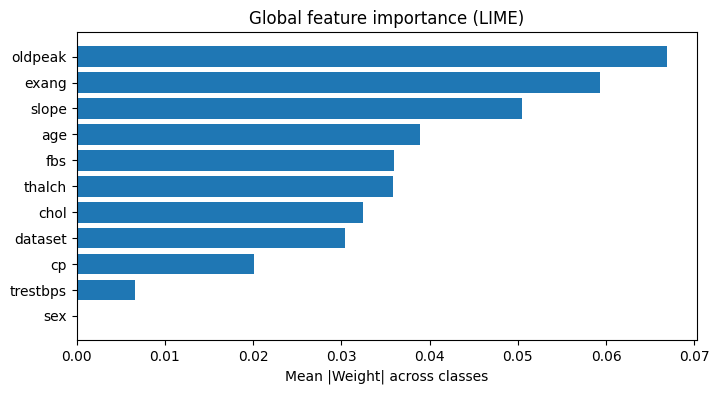

In [9]:
lime(dnn_model, X_train, class_names, sample_pos)

### Sieć neuronowa - SHAP

PermutationExplainer explainer: 734it [02:19,  5.13it/s]                                                               


(733, 11, 5)

Local explanation for class 0


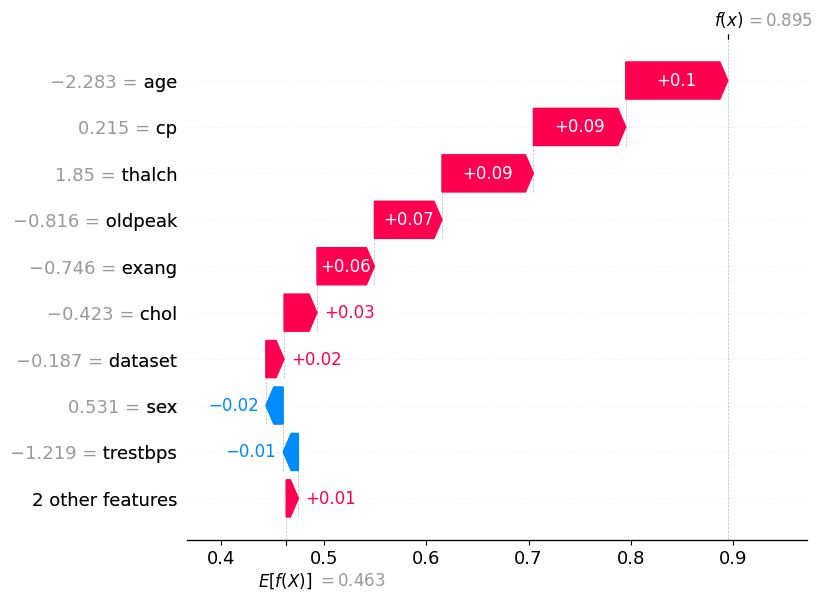


Local explanation for class 1


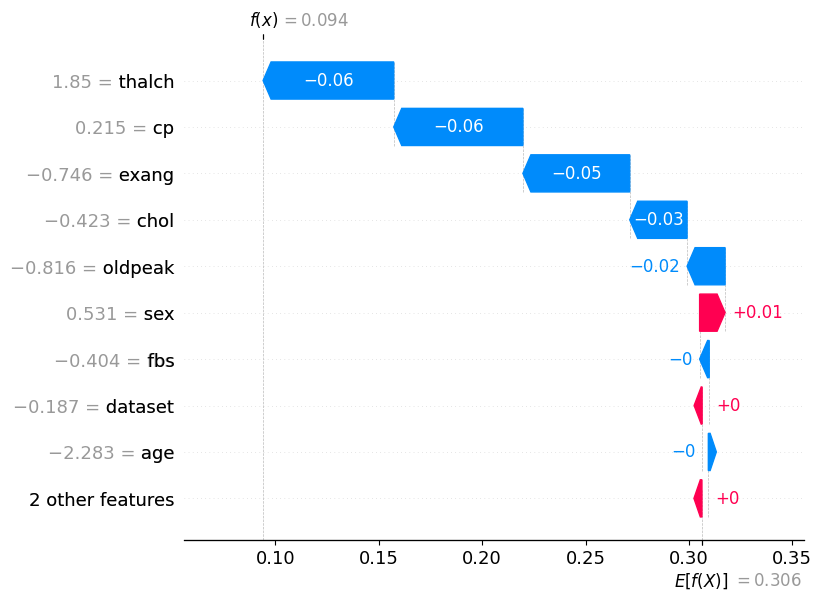


Local explanation for class 2


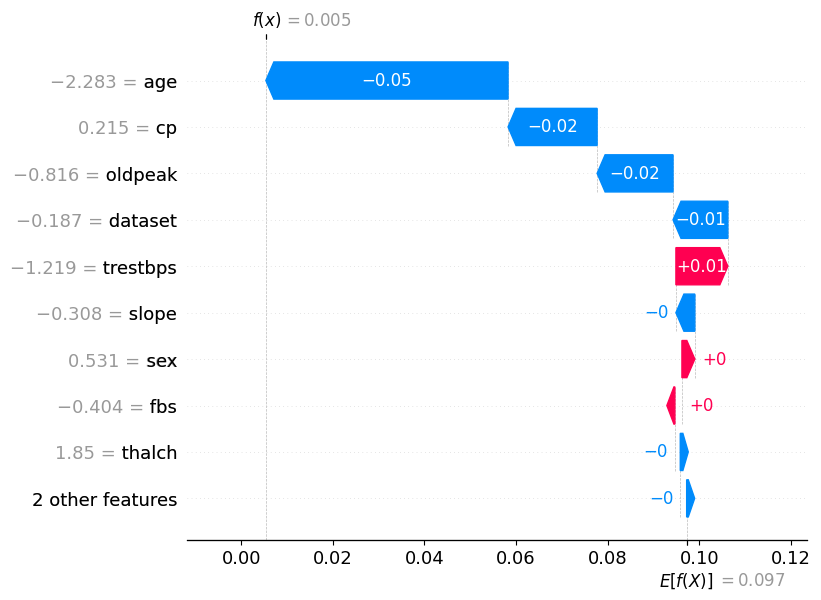


Local explanation for class 3


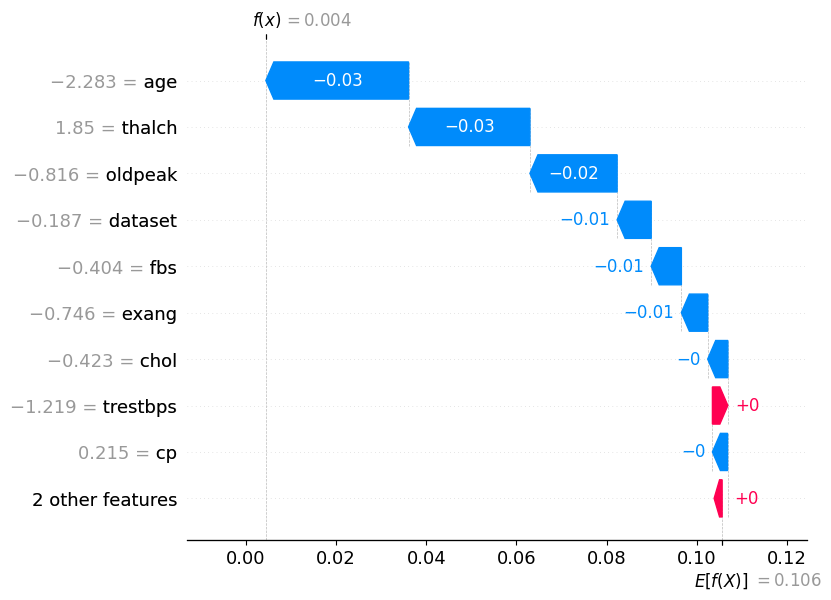


Local explanation for class 4


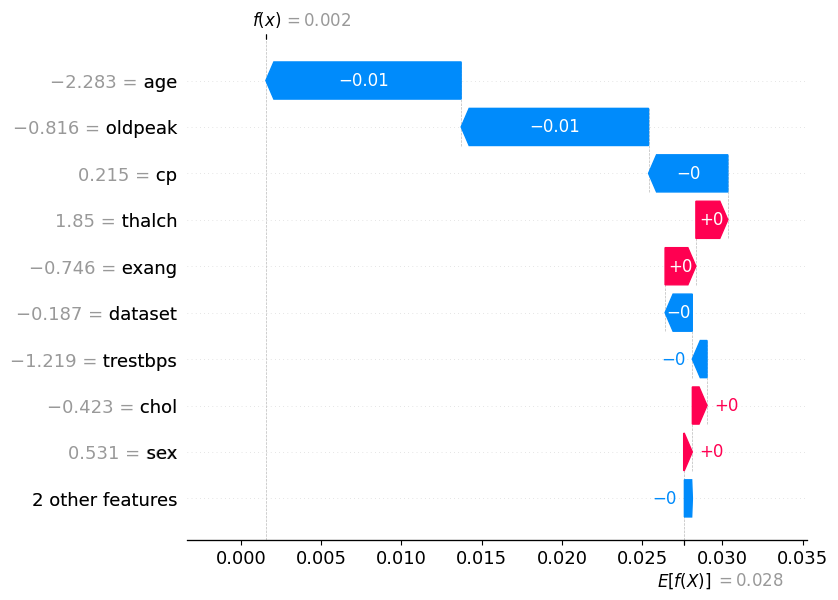

<Figure size 640x480 with 0 Axes>

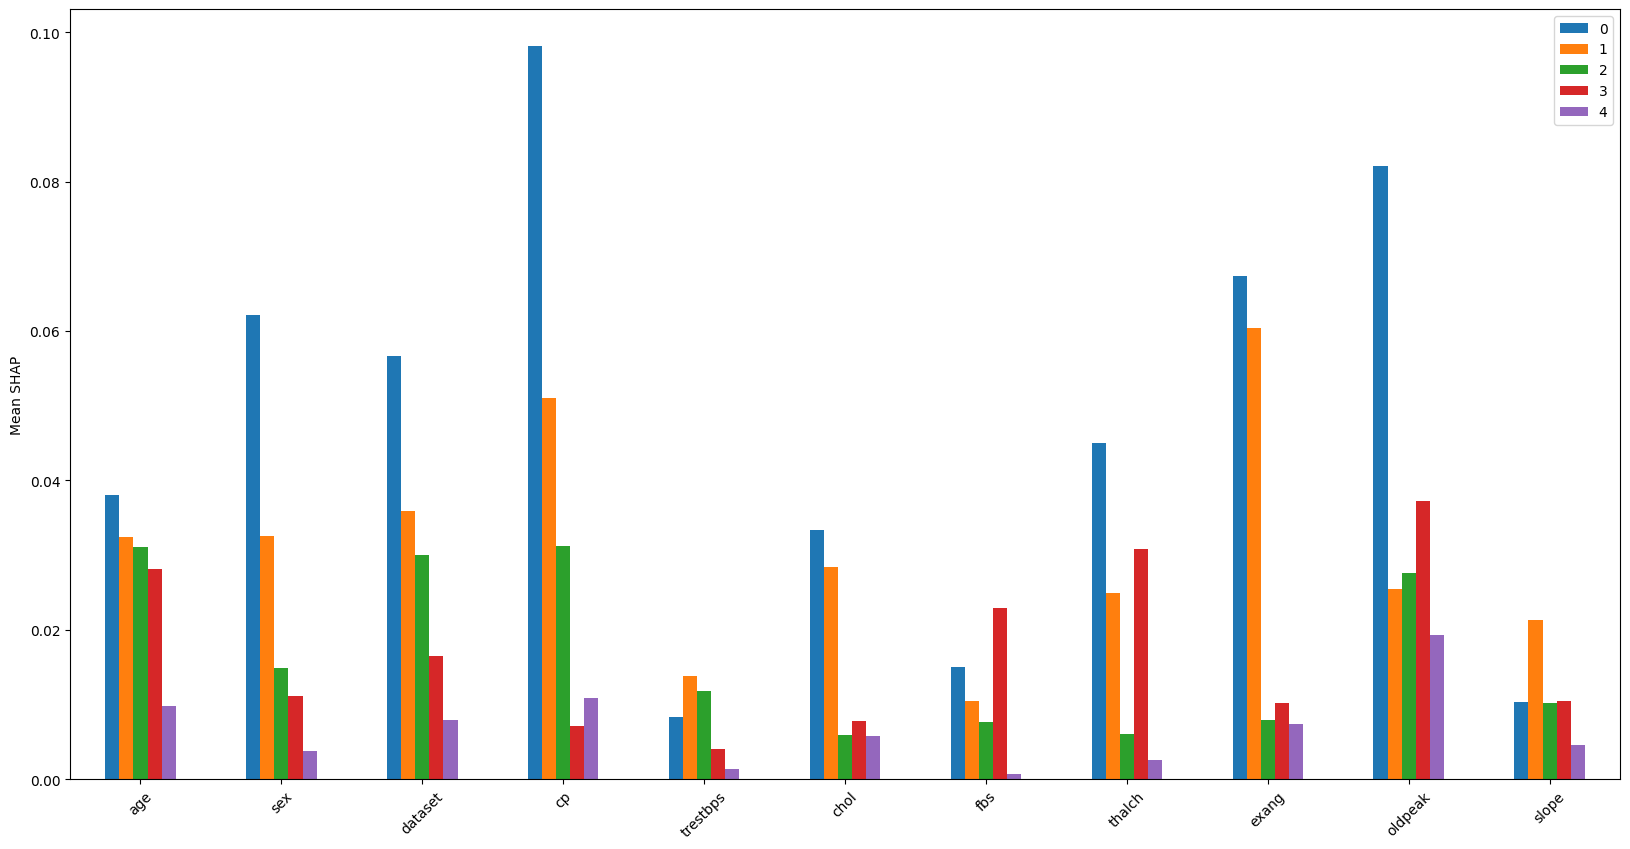

(733, 11)


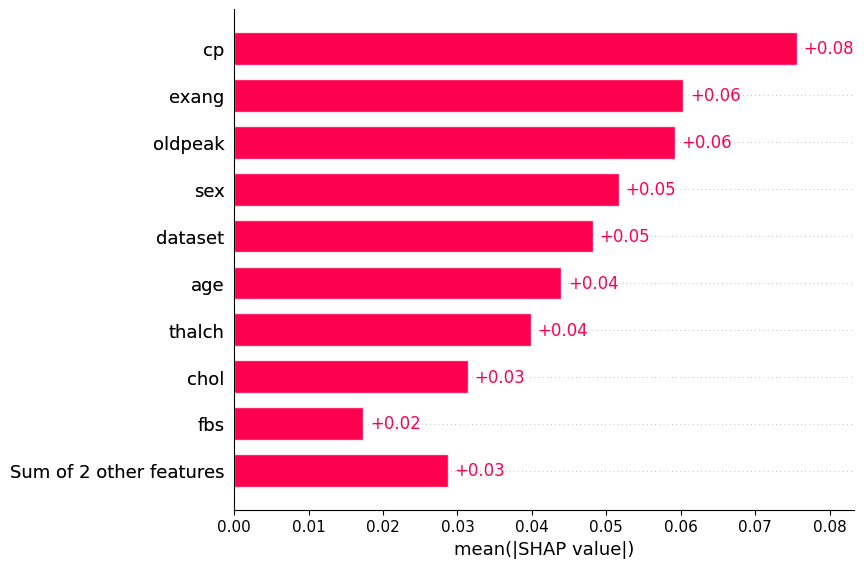

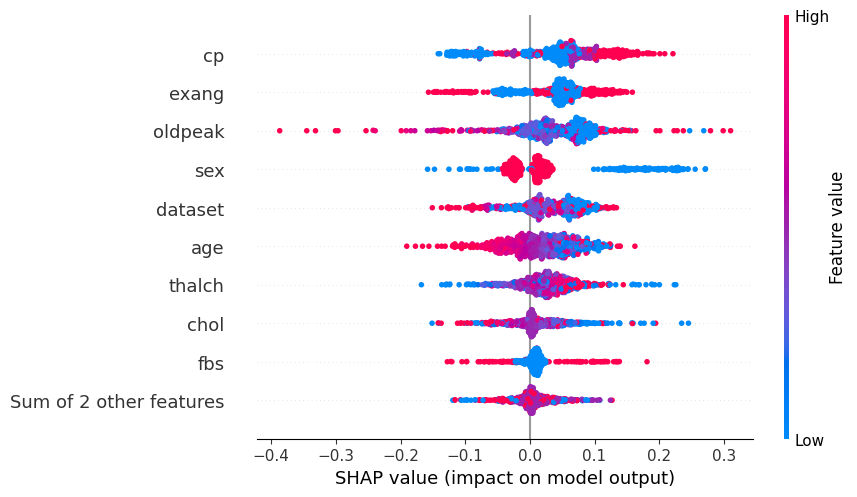

In [10]:
multiclass_shap(dnn_model, X_train, class_names, sample_pos)

### Sieć neuronowa - PFI

oldpeak 0.053 +/- 0.011
dataset 0.045 +/- 0.008
exang   0.043 +/- 0.008
cp      0.041 +/- 0.009
age     0.036 +/- 0.009
thalch  0.029 +/- 0.008
fbs     0.027 +/- 0.006
chol    0.024 +/- 0.008
sex     0.022 +/- 0.008
slope   0.015 +/- 0.005
trestbps0.011 +/- 0.004


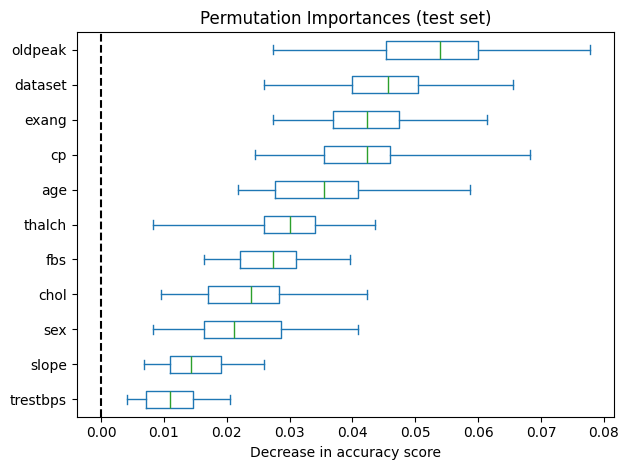

In [23]:
pfi(dnn_model, X_train, y_train)